In [1]:
# Core imports
%matplotlib inline
import warnings, re, os, json, time, math
from pathlib import Path
from datetime import datetime, date, timedelta, timezone

import requests
import pandas as pd
import numpy as np
import h3
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
import urllib.request, ssl

# Calendar / astronomy helpers — both are lightweight, pure-python, no API key needed    
import holidays
from astral import LocationInfo
from astral.sun import sun


warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.3f}'.format)
pd.set_option('display.max_columns', 60)
sns.set_theme(style='whitegrid', font_scale=1.0)

BLUE, ORANGE, RED, GREEN, PURPLE, TEAL = '#1a6bff', '#f59e0b', '#ef4444', '#22c55e', '#8b5cf6', '#06b6d4'
PERIOD_COLORS = {'AM': BLUE, 'MD': ORANGE, 'PM': GREEN, 'EVE': PURPLE, 'NIGHT': RED, 'EARLY': TEAL}
PERIOD_ORDER  = ['EARLY', 'AM', 'MD', 'PM', 'EVE', 'NIGHT']

print(f'h3 version: {h3.__version__}')

h3 version: 4.5.0


In [2]:
# Directory layout
# raw/       -> downloaded files (cached, one file per source per date/month)
# processed/ -> intermediate cleaned tables
# master/    -> final ML-ready CSVs (training + live-grid template)
# plots/     -> saved charts

DATA = Path('../data')
RAW = DATA / 'raw'; RAW.mkdir(parents=True, exist_ok=True)
PROC = DATA / 'processed'; PROC.mkdir(parents=True, exist_ok=True)
MASTER = DATA / 'master'; MASTER.mkdir(parents=True, exist_ok=True)
PLOTS = DATA / 'plots'; PLOTS.mkdir(parents=True, exist_ok=True)

In [3]:
# Global config

H3_RES = 9   # ~174 m edge length, ~0.1 km^2 per cell — fine enough to distinguish
             # one side of an avenue from the other, coarse enough to keep the
             # full-Manhattan grid to a few thousand cells instead of millions.

# Manhattan bounding box (generous — trimmed precisely by the borough polygon in Section 1)
MANHATTAN_BBOX = dict(south=40.679, west=-74.020, north=40.882, east=-73.907)

# NYC TLC taxi zone IDs that fall in Manhattan — used to filter trip data
MANHATTAN_ZONES = {
    4, 12, 13, 24, 41, 42, 43, 45, 48, 50, 68, 74, 75, 79, 87, 88, 90, 100,
    103, 104, 105, 107, 113, 114, 116, 120, 125, 127, 128, 137, 140, 141, 142,
    143, 144, 148, 151, 152, 153, 158, 161, 162, 163, 164, 166, 170, 186, 194,
    202, 209, 211, 224, 229, 230, 231, 232, 233, 234, 236, 237, 238, 239, 243,
    244, 246, 249, 261, 262, 263,
}

# Six dayparts instead of V1's three — finer granularity supports "right now" queries
# at any hour, not just the three DOT survey windows.
PERIOD_WINDOWS = {
    'EARLY': range(0, 7),    # 12am-7am  — overnight / pre-dawn
    'AM':    range(7, 10),   # 7-10am    — morning rush
    'MD':    range(10, 14),  # 10am-2pm  — midday
    'PM':    range(14, 18),  # 2-6pm     — afternoon / PM rush
    'EVE':   range(18, 22),  # 6-10pm    — evening
    'NIGHT': range(22, 24),  # 10pm-12am — late night
}

def hour_to_period(hour):
    # Map an hour (0-23) to one of the six dayparts above.
    for period, hrs in PERIOD_WINDOWS.items():
        if hour in hrs:
            return period
    return None

# Anchor "now" for this run — every live/future feature in Section 13 is built
# relative to this. Re-running the notebook on a different day naturally shifts
# the live grid to that day, which is exactly the "current date" requirement.
RUN_TIMESTAMP = datetime.now()
print(f'Notebook run timestamp (used as "current date/time"): {RUN_TIMESTAMP}')

# Default location if no user GPS is supplied — Times Square, a safe Manhattan default
DEFAULT_USER_LAT, DEFAULT_USER_LON = 40.7580, -73.9855

print(f'H3 resolution: {H3_RES}')
print(f'Dayparts: {list(PERIOD_WINDOWS.keys())}')

Notebook run timestamp (used as "current date/time"): 2026-06-30 12:19:21.907338
H3 resolution: 9
Dayparts: ['EARLY', 'AM', 'MD', 'PM', 'EVE', 'NIGHT']


## Helper Functions

- **`dqr()`** — prints a quick data-quality banner (rows, columns, nulls, date range)
- **`dqp()`** — per-column stats table (dtype, nulls, min/max/mean/unique)
- **`norm_score()`** — min-max rescale to 0-100, used to build every "_score" feature consistently
- **`http_get_json()` / `http_get_cached()`** — small wrappers with retry + on-disk caching so re-running the notebook never re-downloads


In [4]:
def dqr(name, df, date_col=None):
    '''Data Quality Report - prints a summary banner for the dataframe.'''
    n_null = int(df.isnull().sum().sum())
    null_pct = n_null / df.size * 100 if df.size else 0
    print(f'DATA QUALITY REPORT - {name:<42}')
    print(f'Rows:        {df.shape[0]:>10,}')
    print(f'Columns:     {df.shape[1]:>10,}')
    print(f'Null cells:  {n_null:,} ({null_pct:.2f}%)')
    if date_col and date_col in df.columns and len(df):
        lo = str(df[date_col].min())[:10]
        hi = str(df[date_col].max())[:10]
        print(f'Date range:  {lo}  ->  {hi}')


def dqp(df):
    '''Data Quality Profile - per-column stats table.'''
    rows = []
    for col in df.columns:
        s = df[col]
        n_null = int(s.isna().sum())
        row = {
            'feature': col,
            'dtype': str(s.dtype),
            'null_pct': round(n_null / len(s) * 100, 2) if len(s) else 0,
            'n_unique': int(s.nunique()),
        }
        if pd.api.types.is_numeric_dtype(s):
            row['min']  = s.min()
            row['mean'] = s.mean()
            row['max']  = s.max()
        rows.append(row)
    return pd.DataFrame(rows)


def save_dqp(df, name):
    out = PROC / f'dqp_{name}.csv'
    dqp(df).to_csv(out, index=False)
    return out


def norm_score(s):
    '''Min-max rescale a series to 0-100. Flat series -> all zeros.'''
    s = s.astype(float)
    lo, hi = s.min(), s.max()
    if pd.isna(lo) or pd.isna(hi) or hi == lo:
        return pd.Series(np.zeros(len(s)), index=s.index)
    return ((s - lo) / (hi - lo) * 100).round(2)


def http_get_cached(url, cache_path, params=None, timeout=120, is_json=True):
    '''GET a URL with on-disk caching. Returns parsed JSON (list/dict) or raw bytes.'''
    cache_path = Path(cache_path)
    if cache_path.exists():
        if is_json:
            return json.loads(cache_path.read_text())
        return cache_path.read_bytes()
    try:
        r = requests.get(url, params=params, timeout=timeout)
        r.raise_for_status()
    except Exception as e:
        print(f'    request failed: {e}')
        return None
    if is_json:
        data = r.json()
        cache_path.write_text(json.dumps(data))
        return data
    cache_path.write_bytes(r.content)
    return r.content

## 1 · The Manhattan Hex Grid — Full Spatial Universe

Instead of only modelling the 36 DOT
survey corridors, we generate **every H3 cell that covers Manhattan**. This grid
becomes the spatial backbone for the whole notebook:

- Ground-truth pedestrian counts (Section 2) attach to a handful of these cells.
- Every proxy signal (Sections 3-7) attaches to *all* cells that have activity.
- The live feature builder (Section 13) can look up **any** cell a user's GPS
  coordinates fall into — even one with no DOT survey history — because by then
  every cell already has POI density + typical mobility/transit/event patterns.

We pull the official Manhattan borough boundary from NYC Open Data and fill it
with H3 cells via `polygon_to_cells`. If the API is unreachable, we fall back to
a hand-drawn bounding polygon that approximates Manhattan's shape (close enough
for grid generation; it just includes a bit of water at the edges, which is
harmless since those cells will simply have zero activity).


In [ ]:

# Section 1 · Manhattan H3 Grid from manual NYC Borough Boundaries GeoJSON 
#  Single-file policy:
#  NYC Borough Boundaries is one stable GeoJSON file, so it is downloaded
#  manually and read directly. The notebook intentionally does not auto-fetch
#  or fall back to older boundary APIs for this single-file source.

BOROUGH_GEOJSON_PATH = RAW / 'Borough_Boundaries_20260629.geojson'
BOROUGH_DOWNLOAD_PAGE = 'https://data.cityofnewyork.us/City-Government/Borough-Boundaries/gthc-hcne'


def _require_manual_file(path, source_name, download_page):
    '''Return a Path if the manual source exists; otherwise explain exactly what is missing.'''
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(
            f'{source_name} must be downloaded manually before running this notebook.\n'
            f'Expected file: {path}\n'
            f'Download page: {download_page}'
        )
    print(f'{source_name} manual file found: {path}')
    return path


def _parse_geojson_manhattan(geojson):
    '''Extract the largest Manhattan polygon ring from a GeoJSON FeatureCollection.'''
    features = geojson.get('features', [])
    name_fields = ('BoroName', 'boroname', 'boro_name', 'name')

    for feat in features:
        props = feat.get('properties', {})
        name = ''
        for field in name_fields:
            if props.get(field):
                name = str(props.get(field)).strip().lower()
                break

        if name != 'manhattan':
            continue

        geom = feat.get('geometry', {})
        coords = geom.get('coordinates', [])

        if geom.get('type') == 'MultiPolygon':
            rings = [poly[0] for poly in coords if poly]
        elif geom.get('type') == 'Polygon':
            rings = [coords[0]] if coords else []
        else:
            raise ValueError(f"Unsupported Manhattan geometry type: {geom.get('type')}")

        if not rings:
            raise ValueError('Manhattan geometry was found, but it did not contain polygon rings.')

        biggest = max(rings, key=len)
        return [(lat, lon) for lon, lat in biggest]

    raise ValueError('Manhattan feature not found in the Borough Boundaries GeoJSON.')


print('Loading Manhattan boundary from manual GeoJSON...')
borough_path = _require_manual_file(BOROUGH_GEOJSON_PATH, 'NYC Borough Boundaries GeoJSON', BOROUGH_DOWNLOAD_PAGE)
borough_geojson = json.loads(borough_path.read_text(encoding='utf-8'))
manhattan_outline = _parse_geojson_manhattan(borough_geojson)
print(f'Manhattan boundary: {len(manhattan_outline)} vertices')

mn_shape  = h3.LatLngPoly(manhattan_outline)
GRID_HEXES = sorted(h3.polygon_to_cells(mn_shape, H3_RES))

grid_df = pd.DataFrame({'h3_cell': GRID_HEXES})
grid_df['lat'] = grid_df['h3_cell'].apply(lambda c: h3.cell_to_latlng(c)[0])
grid_df['lon'] = grid_df['h3_cell'].apply(lambda c: h3.cell_to_latlng(c)[1])
grid_df.to_csv(PROC / 'manhattan_grid_h3.csv', index=False)

print(f'Manhattan H3 grid (res {H3_RES}): {len(grid_df):,} cells')
print(f'Approx area covered: {len(grid_df) * 0.1:,.0f} km² (Manhattan is ~59 km² of land)')
display(grid_df.head())


Loading Manhattan boundary from manual GeoJSON...
NYC Borough Boundaries GeoJSON manual file found: ..\data\raw\Borough_Boundaries_20260629.geojson
Manhattan boundary: 4785 vertices
Manhattan H3 grid (res 9): 524 cells
Approx area covered: 52 km² (Manhattan is ~59 km² of land)


,h3_cell,lat,lon
0,892a1008803ffff,40.798,-73.975
1,892a1008807ffff,40.795,-73.973
2,892a100880fffff,40.795,-73.977
3,892a1008813ffff,40.801,-73.973
4,892a1008817ffff,40.798,-73.970


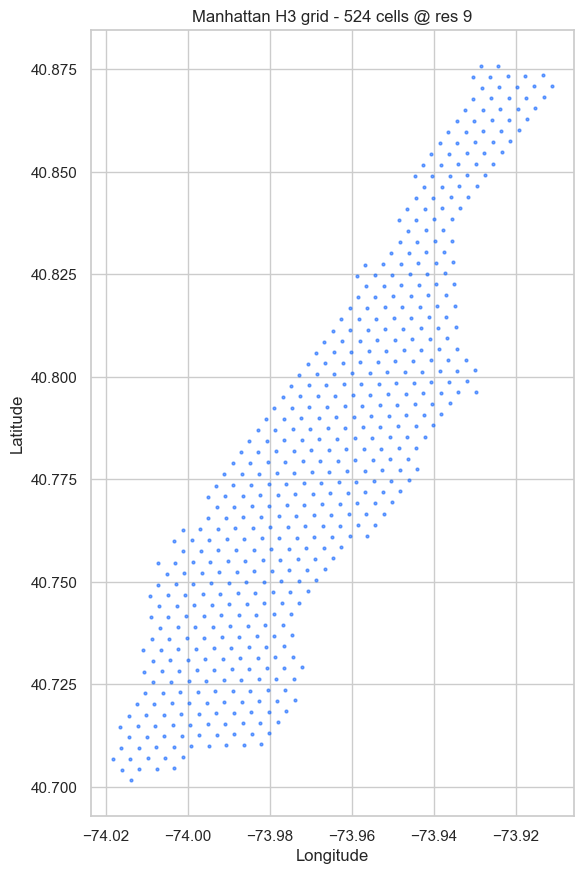

In [6]:
# Quick visual sanity check — does the grid look like Manhattan's shape?
fig, ax = plt.subplots(figsize=(6, 10))
ax.scatter(grid_df['lon'], grid_df['lat'], s=4, color=BLUE, alpha=0.6)
ax.set_title(f'Manhattan H3 grid - {len(grid_df):,} cells @ res {H3_RES}')
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
ax.set_aspect('equal')
plt.tight_layout()
plt.savefig(PLOTS / 'manhattan_grid.png', dpi=120, bbox_inches='tight')
plt.show()



## 2 · Ground Truth — NYC DOT Bi-Annual Pedestrian Counts

Same source as V1 (it is still the only *real* pedestrian-count ground truth
available for Manhattan), but here it plays a narrower role: it supplies the
**label** for whichever grid cells happen to contain a survey corridor. Every
other cell in the grid will get its crowd estimate from the proxy-signal blend
built in Section 11.

The NYC DOT pedestrian count dataset is also a **single source file**, so it is
now handled as a manual CSV download instead of a Socrata API fetch. Download
the CSV once and keep it at:

`raw/Bi-Annual_Pedestrian_Counts_20260629.csv`


In [ ]:

# Section 2 · NYC DOT Bi-Annual Pedestrian Counts from manual CSV 
# Single-file policy:
# This source is one CSV export, so the notebook reads the manually downloaded
# file directly. Multi-file sources later in the notebook still use APIs/monthly URLs.

PED_CSV_PATH = RAW / 'Bi-Annual_Pedestrian_Counts_20260629.csv'
PED_DOWNLOAD_PAGE = 'https://data.cityofnewyork.us/Transportation/Bi-Annual-Pedestrian-Counts/cqsj-cfgu'


def load_dot_pedestrian_counts_manual():
    ped_path = _require_manual_file(PED_CSV_PATH, 'NYC DOT Bi-Annual Pedestrian Counts CSV', PED_DOWNLOAD_PAGE)
    df = pd.read_csv(ped_path)

    # Fix common source capitalisation typo (pM -> PM)
    df.columns = [c.replace('_pM', '_PM') for c in df.columns]

    # Count columns may arrive as strings with commas from CSV export; cast to numeric.
    count_col_pat = re.compile(r'[A-Za-z]+\d{2}_(AM|PM|MD)', re.IGNORECASE)
    for col in df.columns:
        if count_col_pat.match(col):
            df[col] = pd.to_numeric(df[col].astype(str).str.replace(',', '', regex=False),
                                    errors='coerce')

    print(f'Pedestrian counts loaded from manual CSV: {ped_path} ({len(df):,} rows)')
    return df


print('Loading NYC DOT pedestrian counts from manual CSV...')
ped_raw     = load_dot_pedestrian_counts_manual()
ped_man_raw = ped_raw[ped_raw['Borough'] == 'Manhattan'].copy()
print(f'  Manhattan rows: {len(ped_man_raw):,}')


def _parse_wkt_point(wkt):
    '''Parse WKT 'POINT (lon lat)' OR a Socrata GeoJSON dict -> (lat, lon).'''
    if pd.isna(wkt) or wkt is None:
        return None, None
    if isinstance(wkt, dict):
        coords = wkt.get('coordinates', [])
        if len(coords) >= 2:
            return float(coords[1]), float(coords[0])
        return None, None
    m = re.match(r'POINT\s*\(\s*(-?\d+\.?\d*)\s+(-?\d+\.?\d*)\s*\)', str(wkt))
    if not m:
        return None, None
    lon, lat = float(m.group(1)), float(m.group(2))
    return lat, lon


loc_rows = []
for _, row in ped_man_raw.iterrows():
    lat, lon = _parse_wkt_point(row.get('the_geom'))
    if lat is None:
        continue
    desc = f"{row.get('Street_Nam', '')} ({row.get('From_Stree', '')} to {row.get('To_Street', '')})"
    loc_rows.append({
        'location_id': row.get('Loc'), 'lat': lat, 'lon': lon, 'description': desc,
    })

loc_df = pd.DataFrame(loc_rows)
loc_df['h3_cell'] = loc_df.apply(lambda r: h3.latlng_to_cell(r['lat'], r['lon'], H3_RES), axis=1)
loc_df.to_csv(PROC / 'location_geocoded.csv', index=False)

n_on_grid = loc_df['h3_cell'].isin(set(GRID_HEXES)).sum()
print(f'Geocoded {len(loc_df)} Manhattan survey corridors')
print(f'  {n_on_grid}/{len(loc_df)} land on a cell inside the generated grid (expected: all or nearly all)')
display(loc_df.head(8))


Loading NYC DOT pedestrian counts from manual CSV...
NYC DOT Bi-Annual Pedestrian Counts CSV manual file found: ..\data\raw\Bi-Annual_Pedestrian_Counts_20260629.csv
Pedestrian counts loaded from manual CSV: ..\data\raw\Bi-Annual_Pedestrian_Counts_20260629.csv (114 rows)
  Manhattan rows: 36
Geocoded 36 Manhattan survey corridors
  35/36 land on a cell inside the generated grid (expected: all or nearly all)


,location_id,lat,lon,description,h3_cell
0,35,40.705,-74.012,Broad Street (Beaver Street to South William S...,892a1072817ffff
1,36,40.706,-74.013,Broadway (Morris Street to Exchange Place),892a1072813ffff
2,37,40.772,-73.982,Broadway (West 63rd Street to West 64th Street),892a1008b37ffff
3,38,40.716,-74.010,Chambers Street (West Broadway to Greenwich St...,892a1072c63ffff
4,39,40.780,-73.977,Columbus Avenue (West 75th Street to West 76th...,892a1008bb3ffff
5,40,40.719,-73.989,Delancey Street (Orchard Street to Ludlow Street),892a1072ca7ffff
6,41,40.736,-73.993,East 14th Street (Fifth Avenue to University P...,892a100d277ffff
7,42,40.752,-73.977,East 42 Street (Park Avenue to Lexington Avenue),892a100d62bffff


In [ ]:
# Reshape wide - long: one row per corridor x survey-date x period

meta_cols  = ['Loc', 'Borough', 'Street_Nam', 'From_Stree', 'To_Street']
count_cols = [c for c in ped_raw.columns if re.match(r'[A-Za-z]+\d{2}_(AM|PM|MD)', c)]
print(f'Found {len(count_cols)} count columns (survey x period combos)')

SEASON_MONTH = {'May': 5, 'Sept': 9, 'Sep': 9, 'Oct': 10}

long_rows = []
for _, row in ped_man_raw.iterrows():
    for col in count_cols:
        m = re.match(r'([A-Za-z]+)(\d{2})_(AM|PM|MD)', col)
        if not m:
            continue
        season, yy, period = m.groups()
        val = row[col]
        if pd.isna(val):
            continue
        val = float(str(val).replace(',', ''))
        if val < 0:
            continue
        year = 2000 + int(yy)
        month = SEASON_MONTH.get(season, 5)
        long_rows.append({
            'location_id': row['Loc'], 'season': season, 'year': year, 'month': month,
            'survey_date': pd.Timestamp(year=year, month=month, day=15),
            'period': period, 'pedestrians': val,
        })

ped_long = pd.DataFrame(long_rows)
ped_long = ped_long.merge(loc_df[['location_id', 'lat', 'lon', 'h3_cell', 'description']],
                           on='location_id', how='left')

n_matched = ped_long['h3_cell'].notna().sum()
print(f'Reshaped rows: {len(ped_long):,}  ({n_matched:,} with an H3 cell)')

ped_long['ped_score']   = ped_long.groupby(['survey_date', 'period'])['pedestrians'].transform(norm_score)
ped_long['day_of_week'] = ped_long['survey_date'].dt.dayofweek

ped_long.to_csv(PROC / 'pedestrian_long_h3.csv', index=False)
dqr('Pedestrian counts - all survey dates', ped_long, date_col='survey_date')
display(ped_long.head())


Found 108 count columns (survey x period combos)
Reshaped rows: 3,826  (3,826 with an H3 cell)
DATA QUALITY REPORT - Pedestrian counts - all survey dates      
Rows:             3,826
Columns:             13
Null cells:  0 (0.00%)
Date range:  2007-05-15  ->  2025-10-15


,location_id,season,year,month,survey_date,period,pedestrians,lat,lon,h3_cell,description,ped_score,day_of_week
0,35,May,2007,5,2007-05-15,AM,3469.000,40.705,-74.012,892a1072817ffff,Broad Street (Beaver Street to South William S...,27.760,1
1,35,May,2007,5,2007-05-15,PM,3992.000,40.705,-74.012,892a1072817ffff,Broad Street (Beaver Street to South William S...,13.010,1
2,35,May,2007,5,2007-05-15,MD,599.000,40.705,-74.012,892a1072817ffff,Broad Street (Beaver Street to South William S...,2.130,1
3,35,Sept,2007,9,2007-09-15,AM,4214.000,40.705,-74.012,892a1072817ffff,Broad Street (Beaver Street to South William S...,40.060,5
4,35,Sept,2007,9,2007-09-15,PM,12879.000,40.705,-74.012,892a1072817ffff,Broad Street (Beaver Street to South William S...,38.780,5


## 3 · Static Crowd Generators — OpenStreetMap Points of Interest (Overpass API)

This is the single biggest addition over V1. The DOT corridors only tell us
about 36 specific blocks; they say nothing about *why* one cell is busier than
another, and nothing at all about the other ~2,000 cells in the grid.

OpenStreetMap (via the Overpass API, free, no key) gives us a **static
fingerprint per cell**: how many subway entrances, restaurants/bars, shops,
offices, tourist attractions, and schools sit inside it. These counts don't
change day to day, but they are exactly what lets the model say "this cell
looks like Times Square" or "this cell looks like a quiet residential block"
for a location that has *never* had a DOT survey.


In [9]:
# Overpass query categories. Each is a list of (key, value) OSM tags.
POI_CATEGORIES = {
    'poi_subway':   [('railway', 'station'), ('station', 'subway')],
    'poi_dining':   [('amenity', 'restaurant'), ('amenity', 'cafe'), ('amenity', 'bar'), ('amenity', 'fast_food')],
    'poi_retail':   [('shop', '*')],
    'poi_office':   [('office', '*')],
    'poi_tourism':  [('tourism', 'attraction'), ('tourism', 'museum'), ('tourism', 'hotel')],
    'poi_school':   [('amenity', 'school'), ('amenity', 'university'), ('amenity', 'college')],
    'poi_nightlife':[('amenity', 'nightclub'), ('amenity', 'pub')],
}

OVERPASS_URL = 'https://overpass-api.de/api/interpreter'

def _overpass_clause(key, val):
    if val == '*':
        return f'["{key}"]'
    return f'["{key}"="{val}"]'

def _overpass_post(query, timeout=60):
    '''POST one Overpass QL query with correct headers. Returns elements list or raises.'''
    headers = {
        'Content-Type': 'application/x-www-form-urlencoded',
        'Accept':       'application/json',
        'User-Agent':   'ZentraCrowdPredictor/1.0 (research project)',
    }
    r = requests.post(
        OVERPASS_URL,
        data=f'data={requests.utils.quote(query)}',
        headers=headers,
        timeout=timeout + 30,   # requests timeout > server timeout so we see the API error
    )
    r.raise_for_status()
    return r.json().get('elements', [])


def _extract_coords(elements):
    '''Pull (lat, lon) from Overpass elements — handles nodes and way centres.'''
    rows = []
    for el in elements:
        if 'lat' in el:
            rows.append({'lat': el['lat'], 'lon': el['lon']})
        elif 'center' in el:
            rows.append({'lat': el['center']['lat'], 'lon': el['center']['lon']})
    return rows


def fetch_poi_category(cat_name, tag_pairs):
    '''Query Overpass for one POI category, one tag-pair at a time, cached to disk.
    
    Splitting into one request per (key, value) pair keeps each query small enough
    that the public Overpass instance can answer within its timeout window.
    node + way are included in each sub-query so features mapped as polygons
    (e.g. subway station buildings, large shops) are captured via their centre point.
    '''
    cache = RAW / f'osm_{cat_name}.csv'
    if cache.exists():
        return pd.read_csv(cache)

    bbox = f"{MANHATTAN_BBOX['south']},{MANHATTAN_BBOX['west']},{MANHATTAN_BBOX['north']},{MANHATTAN_BBOX['east']}"

    all_rows = []
    for k, v in tag_pairs:
        clause = _overpass_clause(k, v)
        # One tight query per tag pair — timeout 45 s is plenty for a single tag in a small bbox
        query  = f'[out:json][timeout:45];(node{clause}({bbox});way{clause}({bbox}););out center;'
        for attempt in range(4):
            try:
                elements   = _overpass_post(query, timeout=45)
                all_rows  += _extract_coords(elements)
                # Polite pause + small jitter so back-to-back sub-queries don't trigger 429s
                time.sleep(5 + random.uniform(0, 3))
                break
            except Exception as e:
                if attempt < 3:
                    # Exponential back-off with jitter: 30s, 60s, 120s (±10 s)
                    wait = 30 * (2 ** attempt) + random.uniform(0, 10)
                    print(f'    [{cat_name}] {k}={v} attempt {attempt+1} failed ({e}), retry in {wait:.0f}s...')
                    time.sleep(wait)
                else:
                    print(f'    [{cat_name}] {k}={v} permanent error: {e}')

    df = pd.DataFrame(all_rows) if all_rows else pd.DataFrame(columns=['lat', 'lon'])
    df = df.drop_duplicates()
    df.to_csv(cache, index=False)
    return df


poi_frames = {}
for cat, tags in POI_CATEGORIES.items():
    print(f'OSM -> {cat} ...', end='  ')
    df = fetch_poi_category(cat, tags)
    poi_frames[cat] = df
    print(f'{len(df):,} points')
    time.sleep(1)  # be polite to the free Overpass instance


OSM -> poi_subway ...  277 points
OSM -> poi_dining ...  10,498 points
OSM -> poi_retail ...  12,503 points
OSM -> poi_office ...  1,459 points
OSM -> poi_tourism ...  792 points
OSM -> poi_school ...  868 points
OSM -> poi_nightlife ...  81 points


In [10]:
# Assign every POI to an H3 cell, then count per cell per category

poi_hex_counts = grid_df[['h3_cell']].copy()

for cat, df in poi_frames.items():
    if df.empty:
        poi_hex_counts[cat] = 0
        continue
    df = df.copy()
    df['h3_cell'] = df.apply(lambda r: h3.latlng_to_cell(r['lat'], r['lon'], H3_RES), axis=1)
    counts = df.groupby('h3_cell').size().rename(cat)
    poi_hex_counts = poi_hex_counts.merge(counts, on='h3_cell', how='left')
    poi_hex_counts[cat] = poi_hex_counts[cat].fillna(0).astype(int)

poi_hex_counts['poi_total'] = poi_hex_counts[[c for c in poi_hex_counts.columns if c.startswith('poi_')]].sum(axis=1)
poi_hex_counts['poi_density_score'] = norm_score(poi_hex_counts['poi_total'])

poi_hex_counts.to_csv(PROC / 'poi_hex_counts.csv', index=False)
dqr('OSM POI density per H3 cell', poi_hex_counts)
display(poi_hex_counts.sort_values('poi_total', ascending=False).head(10))


DATA QUALITY REPORT - OSM POI density per H3 cell               
Rows:               524
Columns:             10
Null cells:  0 (0.00%)


,h3_cell,poi_subway,poi_dining,poi_retail,poi_office,poi_tourism,poi_school,poi_nightlife,poi_total,poi_density_score
478,892a1072c33ffff,0,60,152,6,5,1,0,224,100.000
455,892a1072883ffff,4,65,76,15,5,1,0,166,74.110
496,892a1072c97ffff,0,82,69,4,3,6,0,164,73.210
500,892a1072cabffff,1,69,87,2,3,0,1,163,72.770
345,892a100d35bffff,0,72,84,1,3,1,0,161,71.880
474,892a1072c23ffff,0,85,65,3,3,3,0,159,70.980
499,892a1072ca7ffff,2,65,63,6,4,4,1,145,64.730
501,892a1072cafffff,1,61,71,6,2,0,0,141,62.950
444,892a10725a7ffff,0,66,59,5,9,1,0,140,62.500
330,892a100d2c7ffff,1,63,58,5,10,0,0,137,61.160


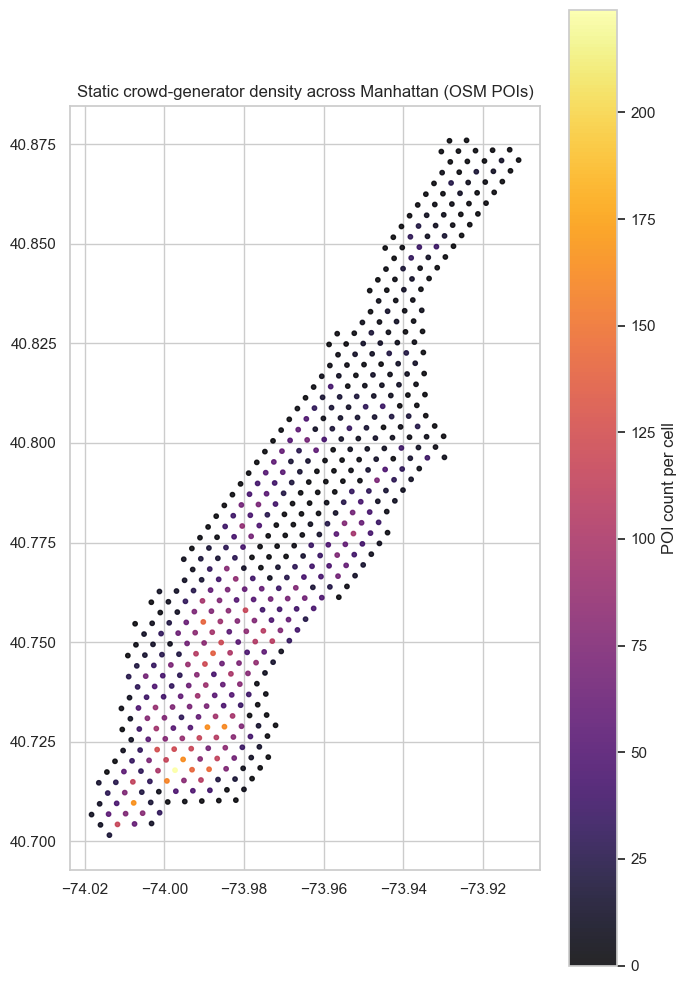

In [ ]:
# EDA — where are the crowd generators concentrated
fig, ax = plt.subplots(figsize=(7, 10))
merged = grid_df.merge(poi_hex_counts, on='h3_cell')
sc = ax.scatter(merged['lon'], merged['lat'], c=merged['poi_total'], cmap='inferno',
                s=10, alpha=0.85)
plt.colorbar(sc, ax=ax, label='POI count per cell')
ax.set_title('Static crowd-generator density across Manhattan (OSM POIs)')
ax.set_aspect('equal')
plt.tight_layout()
plt.savefig(PLOTS / 'poi_density_map.png', dpi=120, bbox_inches='tight')
plt.show()


## 4 · Mobility Demand — TLC Yellow Taxi + HVFHV (Monthly API Files)

Same logic as V1 (Yellow + HVFHV, joined via TLC zone centroids) but run for
**two different purposes**:

1. **Historical**: every DOT survey month, to build the training table.
2. **Reference month**: the most recent fully-published month, to build a
   "typical demand right now" feature for cells/times that have no DOT survey
   history at all — this is what the live feature builder in Section 13 leans on.


In [ ]:
# TLC zone - H3 centroid lookup
TLC_ZONE_CENTROIDS = {
    4: (40.7282, -74.0027), 12: (40.7614, -73.9914), 13: (40.7529, -73.9895),
    24: (40.7135, -74.0083), 41: (40.7517, -73.9757), 42: (40.7648, -73.9808),
    43: (40.7806, -73.9789), 45: (40.7127, -74.0059), 48: (40.7412, -74.0003),
    50: (40.7210, -74.0045), 68: (40.8071, -73.9642), 74: (40.7248, -73.9956),
    75: (40.7189, -73.9893), 79: (40.7464, -73.9786), 87: (40.7692, -73.9838),
    88: (40.7801, -73.9720), 90: (40.7412, -74.0082), 100: (40.7546, -73.9925),
    103: (40.7362, -74.0012), 104: (40.7390, -74.0083), 105: (40.7328, -74.0033),
    107: (40.8011, -73.9537), 113: (40.7628, -73.9661), 114: (40.7756, -73.9588),
    116: (40.7490, -73.9880), 120: (40.7565, -73.9936), 125: (40.7445, -73.9892),
    127: (40.7485, -73.9742), 128: (40.7424, -73.9793), 137: (40.7116, -74.0121),
    140: (40.7076, -74.0128), 141: (40.7047, -74.0131), 142: (40.7566, -73.9867),
    143: (40.7620, -73.9795), 144: (40.7698, -73.9627), 148: (40.7413, -73.9889),
    151: (40.8200, -73.9503), 152: (40.8280, -73.9418), 153: (40.7898, -73.9756),
    158: (40.7533, -73.9784), 161: (40.7585, -73.9921), 162: (40.7579, -73.9965),
    163: (40.7686, -73.9907), 164: (40.7706, -73.9796), 166: (40.7560, -73.9836),
    170: (40.7312, -74.0048), 186: (40.7143, -73.9966), 194: (40.7459, -74.0073),
    202: (40.7531, -73.9822), 209: (40.7213, -74.0109), 211: (40.7095, -74.0095),
    224: (40.7281, -74.0036), 229: (40.7196, -73.9999), 230: (40.7141, -73.9948),
    231: (40.7044, -74.0117), 232: (40.7068, -74.0164), 233: (40.7150, -74.0082),
    234: (40.7223, -74.0069), 236: (40.8100, -73.9557), 237: (40.8060, -73.9530),
    238: (40.8142, -73.9467), 239: (40.7970, -73.9454), 243: (40.7786, -73.9528),
    244: (40.7842, -73.9532), 246: (40.7893, -73.9672), 249: (40.7812, -73.9792),
    261: (40.7561, -73.9949), 262: (40.7530, -73.9780), 263: (40.7480, -73.9720),
}

# Fix (2026-06-30): centroid-only mapping left 463/524 grid cells with
# zero TLC coverage, because every zone's trips all landed on the single H3
# hex containing that zone's centroid point. TLC zones are real polygons
# covering 10-20+ H3 cells each, not single points.
#
# Without the official taxi zone shapefile on hand, we approximate each
# zone's footprint as a k=2 H3 disk around its centroid (a ~870m-radius
# hexagonal patch, roughly matching the size of a real TLC zone). Each
# zone's trips are then split evenly across all cells in its disk via a
# `weight` column, so a hex with N trips counted once, instead of N trips
# all stacked onto one hex while its 10+ neighbors get nothing.
ZONE_DISK_K = 2   # ring radius in H3 cells (~870m at res 9) approximating real zone size

zone_df = pd.DataFrame([
    {'zone_id': zid, 'lat': lat, 'lon': lon} for zid, (lat, lon) in TLC_ZONE_CENTROIDS.items()
])
zone_df['center_h3'] = zone_df.apply(lambda r: h3.latlng_to_cell(r['lat'], r['lon'], H3_RES), axis=1)

# Expand each zone's centroid into a disk of nearby cells
_expanded_rows = []
for _, r in zone_df.iterrows():
    disk_cells = h3.grid_disk(r['center_h3'], ZONE_DISK_K)
    # Only keep cells that are actually part of the Manhattan grid, so trips
    # don't get assigned to hexes the rest of the pipeline never sees
    disk_cells = [c for c in disk_cells if c in set(grid_df['h3_cell'])] if 'grid_df' in dir() else list(disk_cells)
    if not disk_cells:
        disk_cells = [r['center_h3']]   # fallback: at least keep the centroid cell
    for cell in disk_cells:
        _expanded_rows.append({'zone_id': r['zone_id'], 'h3_cell': cell, 'weight': 1.0 / len(disk_cells)})

zone_df = pd.DataFrame(_expanded_rows)
zone_df.to_csv(PROC / 'tlc_zone_h3_lookup.csv', index=False)
print(f'TLC zone lookup: {zone_df["zone_id"].nunique()} Manhattan zones -> '
      f'{zone_df["h3_cell"].nunique()} H3 cells '
      f'(avg {len(zone_df) / zone_df["zone_id"].nunique():.1f} cells/zone, '
      f'was 1 cell/zone before this fix)')


TLC zone lookup: 69 Manhattan zones -> 389 H3 cells (avg 17.7 cells/zone, was 1 cell/zone before this fix)


In [ ]:
TLC_CDN = 'https://d37ci6vzurychx.cloudfront.net/trip-data'

# Era guards 
# Yellow parquet files exist from 2009-01 onward on the CDN, but the 2009-2013
# files use a different schema (lat/lon instead of zone IDs, different column
# names).  HVFHV (Uber/Lyft) only exists from 2019-02 onward.
YELLOW_START  = (2009, 1)   # earliest month with a parquet file on the CDN
HVFHV_START   = (2019, 2)   # HVFHV dataset launch date

# Column-name aliases across all Yellow schema versions 
# Key   = name as it appears in older files
# Value = canonical name used throughout the rest of this notebook
_YELLOW_ALIASES = {
    # pickup datetime
    'Trip_Pickup_DateTime':  'tpep_pickup_datetime',
    'pickup_datetime':       'tpep_pickup_datetime',
    # zone ID  (absent before 2011-01; handled separately via lat/lon)
    'PULocationID':          'PULocationID',          # already canonical
    # fare
    'Fare_Amt':              'fare_amount',
    'fare_Amt':              'fare_amount',
    # distance
    'Trip_Distance':         'trip_distance',
    # lat/lon for pre-zone era (2009-01 - 2010-12)
    # Note: 2009-xx files use Start_Lat/Start_Lon (aliased below).
    # 2010-xx files already use the canonical pickup_latitude/pickup_longitude
    # names directly, so no alias entry is needed for that variant.
    'Start_Lat':             'pickup_latitude',
    'Start_Lon':             'pickup_longitude',
}

def _normalize_yellow_schema(df):
    """Rename legacy Yellow-taxi columns to canonical names in-place."""
    return df.rename(columns={k: v for k, v in _YELLOW_ALIASES.items() if k in df.columns})


def _era(year, month):
    """Return 'pre', 'latlon', or 'zone' depending on the TLC schema era.

    Fix (2026-06-30): the original boundary assumed lat/lon data ran through
    2013-12, with zone IDs starting 2014-01. Direct inspection of the actual
    CDN files showed this is wrong — 2010-05 still has pickup_longitude/
    pickup_latitude columns, but 2011-05 already has PULocationID (zone IDs).
    The real cutover is between 2010-12 and 2011-01. Every month from 2011-01
    onward was being silently skipped ('lat/lon columns missing') because
    _era() told fetch_yellow_month() to look for lat/lon columns on files
    that no longer had them.
    """
    ym = (year, month)
    if ym < YELLOW_START:
        return 'pre'
    if ym < (2011, 1):
        return 'latlon'   # 2009-01 – 2010-12: lat/lon, no zone ID
    return 'zone'         # 2011-01 onward: zone ID column present


def _yellow_columns_for_era(year, month):
    """Return the column list to request from PyArrow for this era's schema."""
    era = _era(year, month)
    if era == 'latlon':
        # Pre-zone files: read lat/lon + pickup time; fare/distance vary by year
        return None   # read ALL columns then filter — avoids FieldRef errors on
                      # files where some columns are simply absent
    # Modern schema — request exactly what we need
    return ['tpep_pickup_datetime', 'PULocationID', 'fare_amount', 'trip_distance']


def fetch_yellow_month(year, month):
    """Download Yellow taxi parquet for one month, handle all schema eras.
    
    Returns a DataFrame with columns:
        pickup_dt, zone_id (NaN for 2009-2013), hour,
        fare_amount, trip_distance, h3_cell (filled for 2009-2013 via lat/lon)
    or None if the month is out of range / download failed.
    """
    era = _era(year, month)
    if era == 'pre':
        print(f'    yellow: skipped — pre-TLC parquet era ({year}-{month:02d})')
        return None

    cache = RAW / f'yellow_{year}_{month:02d}.csv'
    if cache.exists():
        return pd.read_csv(cache)

    url = f'{TLC_CDN}/yellow_tripdata_{year}-{month:02d}.parquet'
    col_request = _yellow_columns_for_era(year, month)
    try:
        # Speed fix (2026-06-30): pd.read_parquet (pyarrow engine) auto-detects
        # http:// URLs via fsspec and uses HTTP range requests to fetch only
        # the byte ranges for the requested columns directly from the file's
        # column-chunk layout, instead of downloading the entire file first
        # like the old requests.get(...).content approach did. Typically a
        # 5-10x reduction in bytes transferred for files with 15-20 columns
        # when only 4 are actually needed.
        df = pd.read_parquet(url, columns=col_request, engine='pyarrow')
    except Exception as e:
        # Fall back to full download if range requests aren't supported
        # for this particular file/server (rare, but keeps things working)
        try:
            import pyarrow.parquet as pq
            import io
            r = requests.get(url, timeout=180)
            r.raise_for_status()
            table = pq.read_table(io.BytesIO(r.content), columns=col_request)
            df = table.to_pandas()
        except Exception as e2:
            print(f'    yellow fetch error ({year}-{month:02d}): {e2}')
            return None

    # Normalise column names across all eras
    df = _normalize_yellow_schema(df)

    # Parse pickup datetime
    dt_col = 'tpep_pickup_datetime'
    if dt_col not in df.columns:
        print(f'    yellow: no pickup datetime column after normalisation ({year}-{month:02d}), skipping')
        return None
    df['pickup_dt'] = pd.to_datetime(df[dt_col], errors='coerce')
    df = df.dropna(subset=['pickup_dt'])
    df['hour'] = df['pickup_dt'].dt.hour

    if era == 'latlon':
        # 2009-2013: assign H3 directly from lat/lon, set zone_id = NaN
        if 'pickup_latitude' in df.columns and 'pickup_longitude' in df.columns:
            lat_ok = df['pickup_latitude'].between(40.679, 40.882)
            lon_ok = df['pickup_longitude'].between(-74.020, -73.907)
            df = df[lat_ok & lon_ok].copy()
            df['h3_cell'] = df.apply(
                lambda r: h3.latlng_to_cell(r['pickup_latitude'], r['pickup_longitude'], H3_RES),
                axis=1
            )
        else:
            print(f'    yellow: lat/lon columns missing for {year}-{month:02d}, skipping')
            return None
        df['zone_id'] = pd.NA
    else:
        # 2014+: filter by Manhattan zone IDs
        if 'PULocationID' not in df.columns:
            print(f'    yellow: PULocationID missing for {year}-{month:02d}, skipping')
            return None
        df = df.rename(columns={'PULocationID': 'zone_id'})
        df = df[df['zone_id'].isin(MANHATTAN_ZONES)].copy()
        df['h3_cell'] = pd.NA   # will be filled by zone_df join in fetch_tlc_h3

    # Keep only the columns the aggregator needs
    keep = ['pickup_dt', 'zone_id', 'hour', 'h3_cell']
    for opt in ['fare_amount', 'trip_distance']:
        if opt in df.columns:
            keep.append(opt)
        else:
            df[opt] = np.nan
            keep.append(opt)
    df = df[keep].copy()
    df.to_csv(cache, index=False)
    return df


def fetch_hvfhv_month(year, month):
    """Download HVFHV (Uber/Lyft) parquet for one month, filter to Manhattan zones.
    
    HVFHV data only exists from 2019-02 onward; earlier months return None cleanly.
    """
    if (year, month) < HVFHV_START:
        return None   # silent — expected gap, not an error

    cache = RAW / f'hvfhv_{year}_{month:02d}.csv'
    if cache.exists():
        return pd.read_csv(cache)

    url = f'{TLC_CDN}/fhvhv_tripdata_{year}-{month:02d}.parquet'
    hvfhv_cols = ['pickup_datetime', 'PULocationID', 'base_passenger_fare', 'trip_miles']
    try:
        # Speed fix (2026-06-30): same HTTP-range column pruning as the
        # Yellow block above. HVFHV monthly files are often even larger
        # than Yellow's (more Uber/Lyft trips than yellow cab trips per
        # month in recent years), so this matters more here.
        df = pd.read_parquet(url, columns=hvfhv_cols, engine='pyarrow')
    except Exception as e:
        try:
            import pyarrow.parquet as pq
            import io
            r = requests.get(url, timeout=180)
            r.raise_for_status()
            table = pq.read_table(io.BytesIO(r.content), columns=hvfhv_cols)
            df = table.to_pandas()
        except Exception as e2:
            print(f'    hvfhv fetch error ({year}-{month:02d}): {e2}')
            return None

    df = df.rename(columns={
        'pickup_datetime':     'pickup_dt',
        'PULocationID':        'zone_id',
        'base_passenger_fare': 'fare_amount',
        'trip_miles':          'trip_distance',
    })
    df = df[df['zone_id'].isin(MANHATTAN_ZONES)].copy()
    df['pickup_dt'] = pd.to_datetime(df['pickup_dt'], errors='coerce')
    df = df.dropna(subset=['pickup_dt'])
    df['hour'] = df['pickup_dt'].dt.hour
    df['h3_cell'] = pd.NA   # filled by zone_df join in fetch_tlc_h3
    df.to_csv(cache, index=False)
    return df


def fetch_tlc_h3(year, month, label):
    """Combine Yellow + HVFHV for one month, join zone->H3, aggregate to (h3_cell, period).

    Handles all three eras transparently:
    - pre-2009      → returns None (skipped upstream, but guarded here too)
    - 2009-2013     → Yellow only, h3_cell already set via lat/lon
    - 2014-2018     → Yellow only (zone ID), joined via zone_df
    - 2019+         → Yellow + HVFHV, both joined via zone_df
    """
    cache = RAW / f'tlc_h3_combined_{label}.csv'
    if cache.exists():
        return pd.read_csv(cache)

    yellow = fetch_yellow_month(year, month)
    hvfhv  = fetch_hvfhv_month(year, month)
    if yellow is None and hvfhv is None:
        return None

    parts = []

    if yellow is not None and not yellow.empty:
        y = yellow.copy()
        # For the latlon era h3_cell is already populated; for zone era, join now
        y['period'] = y['hour'].apply(hour_to_period)
        y = y.dropna(subset=['period'])

        if y['h3_cell'].isna().all() and 'zone_id' in y.columns:
            # Fix (2026-06-30, memory-safe revision): the original fix fanned
            # out every trip row across each zone's disk of cells BEFORE
            # aggregating, which explodes a 12M-trip month into 200M+ rows
            # and blows past available memory. Instead, aggregate to
            # (zone_id, period) FIRST — a tiny table, ~69 zones x 6 periods —
            # then fan THAT small table out across each zone's disk cells.
            # Same correct result (trips still split across a zone's real
            # footprint instead of stacked on one centroid hex), but the
            # expensive fan-out only ever touches a few hundred rows instead
            # of millions.
            zone_agg = y.groupby(['zone_id', 'period']).agg(
                tlc_yellow_trips=('zone_id', 'count'),
                tlc_yellow_avg_fare=('fare_amount', 'mean'),
            ).reset_index()
            zone_agg = zone_agg.merge(zone_df[['zone_id', 'h3_cell', 'weight']], on='zone_id', how='left')
            zone_agg['tlc_yellow_trips'] = zone_agg['tlc_yellow_trips'] * zone_agg['weight']
            agg = zone_agg.groupby(['h3_cell', 'period']).agg(
                tlc_yellow_trips=('tlc_yellow_trips', 'sum'),
                tlc_yellow_avg_fare=('tlc_yellow_avg_fare', 'mean'),
            ).reset_index()
        else:
            # latlon era already has a real h3_cell per trip, no fan-out needed
            agg = y.groupby(['h3_cell', 'period']).agg(
                tlc_yellow_trips=('zone_id', 'count'),
                tlc_yellow_avg_fare=('fare_amount', 'mean'),
            ).reset_index()
        agg = agg.dropna(subset=['h3_cell'])
        parts.append(agg)

    if hvfhv is not None and not hvfhv.empty:
        f = hvfhv.copy()
        # Fix (2026-06-30, memory-safe revision): same pre-aggregate-then-fan-out
        # approach as the Yellow block above — aggregate to (zone_id, period)
        # first (tiny), then fan that small table out across each zone's disk.
        f['period'] = f['hour'].apply(hour_to_period)
        f = f.dropna(subset=['period'])
        zone_agg = f.groupby(['zone_id', 'period']).agg(
            tlc_hvfhv_trips=('zone_id', 'count'),
            tlc_hvfhv_avg_fare=('fare_amount', 'mean'),
        ).reset_index()
        zone_agg = zone_agg.merge(zone_df[['zone_id', 'h3_cell', 'weight']], on='zone_id', how='left')
        zone_agg['tlc_hvfhv_trips'] = zone_agg['tlc_hvfhv_trips'] * zone_agg['weight']
        agg = zone_agg.groupby(['h3_cell', 'period']).agg(
            tlc_hvfhv_trips=('tlc_hvfhv_trips', 'sum'),
            tlc_hvfhv_avg_fare=('tlc_hvfhv_avg_fare', 'mean'),
        ).reset_index()
        agg = agg.dropna(subset=['h3_cell'])
        parts.append(agg)

    if not parts:
        return None

    out = parts[0]
    for p in parts[1:]:
        out = out.merge(p, on=['h3_cell', 'period'], how='outer')

    for c in ['tlc_yellow_trips', 'tlc_hvfhv_trips']:
        if c not in out.columns:
            out[c] = 0
        out[c] = out[c].fillna(0)

    # Fix (2026-06-30): fetch_tlc_h3() pulls one full calendar month of trips
    # but tags every row with a single day's label (the DOT survey date).
    # Without normalising, tlc_yellow_trips for "one day" was actually a full
    # month's total — e.g. 14M citywide trips in May 2011 landed entirely on
    # the 2011-05-15 label, inflating per-cell counts ~30x versus a real day.
    # Divide by the number of days in that month so the value represents a
    # typical single day's volume for that cell + period, consistent with
    # how weather/POI features are already used as monthly-representative
    # single-day proxies elsewhere in this notebook.
    import calendar as _calendar
    _days_in_month = _calendar.monthrange(year, month)[1]
    out['tlc_yellow_trips'] = out['tlc_yellow_trips'] / _days_in_month
    out['tlc_hvfhv_trips']  = out['tlc_hvfhv_trips']  / _days_in_month

    out['tlc_trip_count'] = out['tlc_yellow_trips'] + out['tlc_hvfhv_trips']
    out['tlc_load_score'] = norm_score(out['tlc_trip_count'])
    out['survey_date'] = label
    out.to_csv(cache, index=False)
    return out



In [14]:
# Run TLC for every DOT survey month (historical) + the latest fully-available month (reference)

FAST_MODE = False  # set True to only process the 2 most recent dates while testing

survey_dates = (
    ped_long[['year', 'month', 'survey_date']]
    .drop_duplicates().sort_values('survey_date').reset_index(drop=True)
)
if FAST_MODE:
    survey_dates = survey_dates.tail(2)

# TLC publishes with a ~2 month lag — the reference month anchors live/future features
ref_dt = (RUN_TIMESTAMP.replace(day=1) - timedelta(days=60))
REFERENCE_MONTH = (ref_dt.year, ref_dt.month)
print(f'Reference month for live features: {REFERENCE_MONTH[0]}-{REFERENCE_MONTH[1]:02d}')
print()

tlc_parts = []
skipped_pre_era  = []
skipped_no_data  = []

for _, srow in survey_dates.iterrows():
    y, m, label = int(srow['year']), int(srow['month']), str(srow['survey_date'])[:10]

    era = _era(y, m)
    if era == 'pre':
        skipped_pre_era.append(label)
        continue

    print(f'TLC -> {label} [{era}] ...', end='  ')
    result = fetch_tlc_h3(y, m, label)
    if result is not None:
        tlc_parts.append(result)
        n_yellow = int(result['tlc_yellow_trips'].sum()) if 'tlc_yellow_trips' in result else 0
        n_hvfhv  = int(result['tlc_hvfhv_trips'].sum())  if 'tlc_hvfhv_trips'  in result else 0
        print(f'{len(result)} H3-period rows  |  yellow trips: {n_yellow:,}  hvfhv trips: {n_hvfhv:,}')
    else:
        skipped_no_data.append(label)
        print('no data returned')

if skipped_pre_era:
    print(f'\nSkipped {len(skipped_pre_era)} months before TLC parquet era '
          f'({YELLOW_START[0]}-{YELLOW_START[1]:02d}): '
          f'{skipped_pre_era[0]} … {skipped_pre_era[-1]}')
if skipped_no_data:
    print(f'Skipped {len(skipped_no_data)} months with no data returned: {skipped_no_data}')

print(f'\nTLC -> reference month {REFERENCE_MONTH} ...', end='  ')
tlc_reference = fetch_tlc_h3(REFERENCE_MONTH[0], REFERENCE_MONTH[1], 'reference')
print(f'{len(tlc_reference)} rows' if tlc_reference is not None else 'failed')

tlc_h3_all = pd.concat(tlc_parts, ignore_index=True) if tlc_parts else pd.DataFrame()
if not tlc_h3_all.empty:
    tlc_h3_all['survey_date'] = pd.to_datetime(tlc_h3_all['survey_date'])
    tlc_h3_all.to_csv(PROC / 'tlc_h3_all_dates.csv', index=False)
    dqr('TLC H3 - historical survey months', tlc_h3_all, date_col='survey_date')
if tlc_reference is not None:
    tlc_reference.to_csv(PROC / 'tlc_h3_reference.csv', index=False)


Reference month for live features: 2026-04

TLC -> 2009-05-15 [latlon] ...  10736 H3-period rows  |  yellow trips: 0  hvfhv trips: 0
TLC -> 2009-09-15 [latlon] ...  11221 H3-period rows  |  yellow trips: 0  hvfhv trips: 0
TLC -> 2010-05-15 [latlon] ...  11169 H3-period rows  |  yellow trips: 0  hvfhv trips: 0
TLC -> 2010-09-15 [latlon] ...  11465 H3-period rows  |  yellow trips: 0  hvfhv trips: 0
TLC -> 2011-05-15 [zone] ...  2334 H3-period rows  |  yellow trips: 453,063  hvfhv trips: 0
TLC -> 2011-09-15 [zone] ...  2334 H3-period rows  |  yellow trips: 434,523  hvfhv trips: 0
TLC -> 2012-05-15 [zone] ...  2334 H3-period rows  |  yellow trips: 405,178  hvfhv trips: 0
TLC -> 2012-09-15 [zone] ...  2334 H3-period rows  |  yellow trips: 433,277  hvfhv trips: 0
TLC -> 2013-05-15 [zone] ...  2334 H3-period rows  |  yellow trips: 429,432  hvfhv trips: 0
TLC -> 2013-09-15 [zone] ...  2334 H3-period rows  |  yellow trips: 424,991  hvfhv trips: 0
TLC -> 2014-05-15 [zone] ...  2334 H3-period row

In [15]:
f = fetch_hvfhv_month(2019, 5)
print("Rows:", len(f) if f is not None else "None (fetch failed)")
if f is not None:
    print("Columns:", f.columns.tolist())
    print("zone_id dtype:", f['zone_id'].dtype)
    print("zone_id sample:", f['zone_id'].head(10).tolist())
    print()
    print("zone_df zone_id dtype:", zone_df['zone_id'].dtype)
    print("zone_df zone_id sample:", zone_df['zone_id'].head(10).tolist())
    print()
    overlap = set(f['zone_id'].unique()) & set(zone_df['zone_id'].unique())
    print("Overlapping zone_ids between hvfhv data and zone_df:", len(overlap))

Rows: 9581647
Columns: ['pickup_dt', 'zone_id', 'fare_amount', 'trip_distance', 'hour', 'h3_cell']
zone_id dtype: int64
zone_id sample: [88, 13, 234, 234, 137, 234, 114, 148, 87, 230]

zone_df zone_id dtype: int64
zone_df zone_id sample: [4, 4, 4, 4, 4, 4, 4, 4, 4, 4]

Overlapping zone_ids between hvfhv data and zone_df: 67


## 5 · Citi Bike — Station Density & Trip Volume (Monthly API Files)

New data source vs V1. Citi Bike trip history is published monthly as open CSV
archives. Stations are fixed points, so we get a clean (lat, lon) -> H3 join,
and trip start/end counts per cell per daypart are a strong proxy for street-
level pedestrian + cyclist activity that taxis and the subway don't capture
(e.g. park edges, waterfront greenways, residential blocks).


In [16]:
CITIBIKE_BASE = 'https://s3.amazonaws.com/tripdata'

def _citibike_candidate_urls(year, month):
    """Citi Bike's S3 bucket has used several different filename conventions
    over the years. Build a list of candidate URLs and try each until one
    works, instead of assuming a single fixed pattern."""
    label = f'{year}{month:02d}'
    candidates = [
        f'{CITIBIKE_BASE}/{label}-citibike-tripdata.csv.zip',  # most common (2013-2023ish)
        f'{CITIBIKE_BASE}/{label}-citibike-tripdata.zip',      # some 2024+ months drop ".csv"
        f'{CITIBIKE_BASE}/{year}-citibike-tripdata.zip',       # a few early years shipped as one yearly zip
    ]
    return candidates


def fetch_citibike_month(year, month):
    '''Download one month of Citi Bike trips, filter to Manhattan-area stations, cache.'''
    label = f'{year}{month:02d}'
    cache = RAW / f'citibike_{label}.csv'
    if cache.exists():
        return pd.read_csv(cache)

    import zipfile, io
    df = None
    last_err = None
    for zip_url in _citibike_candidate_urls(year, month):
        try:
            r = requests.get(zip_url, timeout=180)
            r.raise_for_status()
            zf = zipfile.ZipFile(io.BytesIO(r.content))
            # yearly zips contain one CSV per month - filter to files matching this month if present
            csv_names = [n for n in zf.namelist() if n.lower().endswith('.csv') and '__MACOSX' not in n]
            month_tag = f'{year}{month:02d}'
            matching = [n for n in csv_names if month_tag in n.replace('-', '')]
            inner = matching[0] if matching else csv_names[0]
            df = pd.read_csv(zf.open(inner))
            break  # success - stop trying other candidates
        except Exception as e:
            last_err = e
            continue

    if df is None:
        print(f'    citibike fetch error ({year}-{month:02d}): {last_err}')
        return None

    # Citi Bike schema has changed names over the years - normalise defensively
    rename_map = {
        'started_at': 'start_dt', 'starttime': 'start_dt', 'Start Time': 'start_dt',
        'start_lat': 'lat', 'start station latitude': 'lat', 'Start Station Latitude': 'lat',
        'start_lng': 'lon', 'start station longitude': 'lon', 'Start Station Longitude': 'lon',
    }
    df = df.rename(columns={k: v for k, v in rename_map.items() if k in df.columns})
    keep = [c for c in ['start_dt', 'lat', 'lon'] if c in df.columns]
    df = df[keep].dropna()
    if 'start_dt' in df.columns:
        df['start_dt'] = pd.to_datetime(df['start_dt'], errors='coerce')
        df = df.dropna(subset=['start_dt'])
        df['hour'] = df['start_dt'].dt.hour

    bbox = MANHATTAN_BBOX
    df = df[(df['lat'].between(bbox['south'], bbox['north'])) &
            (df['lon'].between(bbox['west'], bbox['east']))]
    df.to_csv(cache, index=False)
    return df


def fetch_citibike_h3(year, month, label):
    cache = RAW / f'citibike_h3_{label}.csv'
    if cache.exists():
        return pd.read_csv(cache)
    df = fetch_citibike_month(year, month)
    if df is None or df.empty:
        return None
    df = df.copy()
    df['h3_cell'] = df.apply(lambda r: h3.latlng_to_cell(r['lat'], r['lon'], H3_RES), axis=1)
    df['period'] = df['hour'].apply(hour_to_period)
    agg = df.groupby(['h3_cell', 'period']).size().rename('citibike_trip_count').reset_index()
    agg['citibike_load_score'] = norm_score(agg['citibike_trip_count'])
    agg['survey_date'] = label
    agg.to_csv(cache, index=False)
    return agg


citibike_parts = []
for _, srow in survey_dates.iterrows():
    y, m, label = int(srow['year']), int(srow['month']), str(srow['survey_date'])[:10]
    print(f'Citi Bike -> {label} ...', end='  ')
    result = fetch_citibike_h3(y, m, label)
    if result is not None:
        citibike_parts.append(result)
        print(f'{len(result)} H3-period rows')
    else:
        print('skipped (Citi Bike launched mid-2013, or download failed)')

print(f'Citi Bike -> reference month {REFERENCE_MONTH} ...', end='  ')
citibike_reference = fetch_citibike_h3(REFERENCE_MONTH[0], REFERENCE_MONTH[1], 'reference')
print(f'{len(citibike_reference)} rows' if citibike_reference is not None else 'failed')

citibike_h3_all = pd.concat(citibike_parts, ignore_index=True) if citibike_parts else pd.DataFrame()
if not citibike_h3_all.empty:
    citibike_h3_all['survey_date'] = pd.to_datetime(citibike_h3_all['survey_date'])
    citibike_h3_all.to_csv(PROC / 'citibike_h3_all_dates.csv', index=False)
    dqr('Citi Bike H3 - historical survey months', citibike_h3_all, date_col='survey_date')
if citibike_reference is not None:
    citibike_reference.to_csv(PROC / 'citibike_h3_reference.csv', index=False)


Citi Bike -> 2007-05-15 ...      citibike fetch error (2007-05): 404 Client Error: Not Found for url: https://s3.amazonaws.com/tripdata/2007-citibike-tripdata.zip
skipped (Citi Bike launched mid-2013, or download failed)
Citi Bike -> 2007-09-15 ...      citibike fetch error (2007-09): 404 Client Error: Not Found for url: https://s3.amazonaws.com/tripdata/2007-citibike-tripdata.zip
skipped (Citi Bike launched mid-2013, or download failed)
Citi Bike -> 2008-05-15 ...      citibike fetch error (2008-05): 404 Client Error: Not Found for url: https://s3.amazonaws.com/tripdata/2008-citibike-tripdata.zip
skipped (Citi Bike launched mid-2013, or download failed)
Citi Bike -> 2008-09-15 ...      citibike fetch error (2008-09): 404 Client Error: Not Found for url: https://s3.amazonaws.com/tripdata/2008-citibike-tripdata.zip
skipped (Citi Bike launched mid-2013, or download failed)
Citi Bike -> 2009-05-15 ...      citibike fetch error (2009-05): 404 Client Error: Not Found for url: https://s3.ama

## 6 · MTA Subway — Hourly Ridership (2020+)

In [17]:
MTA_START_YEAR = 2020

def fetch_mta_h3(label, target_date=None):
    '''Download MTA subway ridership for one date (or the latest available date if
    target_date is None), assign stations to H3 cells, aggregate to (h3_cell, period).'''
    cache = RAW / f'mta_h3_{label}.csv'
    if cache.exists():
        return pd.read_csv(cache)

    if target_date is None:
        return None
    if target_date[:4] < str(MTA_START_YEAR):
        return None

    params = {
        '$where': (
            f"transit_timestamp >= '{target_date}T00:00:00' "
            f"AND transit_timestamp < '{target_date}T23:59:59' "
            f"AND borough = 'Manhattan' AND transit_mode = 'subway'"
        ),
        '$select': 'transit_timestamp,station_complex,ridership,transfers,latitude,longitude',
        '$limit': 50000,
    }
    try:
        r = requests.get('https://data.ny.gov/resource/5wq4-mkjj.json', params=params, timeout=120)
        r.raise_for_status()
        mta = pd.DataFrame(r.json())
    except Exception as e:
        print(f'    MTA fetch error: {e}')
        return None
    if mta.empty or 'latitude' not in mta.columns:
        return None

    mta['transit_timestamp'] = pd.to_datetime(mta['transit_timestamp'], errors='coerce')
    mta['ridership'] = pd.to_numeric(mta['ridership'], errors='coerce')
    mta['transfers'] = pd.to_numeric(mta.get('transfers', pd.Series(dtype=float)), errors='coerce').fillna(0)
    mta['lat'] = pd.to_numeric(mta['latitude'], errors='coerce')
    mta['lon'] = pd.to_numeric(mta['longitude'], errors='coerce')
    mta = mta.dropna(subset=['lat', 'lon', 'ridership'])
    mta = mta[mta['ridership'] >= 0]

    mta['h3_cell'] = mta.apply(lambda r: h3.latlng_to_cell(r['lat'], r['lon'], H3_RES), axis=1)
    mta['period'] = mta['transit_timestamp'].dt.hour.apply(hour_to_period)
    mta = mta.dropna(subset=['period'])

    agg = mta.groupby(['h3_cell', 'period']).agg(
        mta_ridership_total=('ridership', 'sum'),
        mta_ridership_avg=('ridership', 'mean'),
        mta_station_count=('station_complex', 'nunique'),
        mta_transfers_total=('transfers', 'sum'),
    ).reset_index()
    agg['mta_load_score'] = norm_score(agg['mta_ridership_total'])
    agg['survey_date'] = label
    agg.to_csv(cache, index=False)
    return agg


mta_parts = []
for _, srow in survey_dates.iterrows():
    label = str(srow['survey_date'])[:10]
    print(f'MTA -> {label} ...', end='  ')
    result = fetch_mta_h3(label, target_date=label)
    if result is not None:
        mta_parts.append(result)
        print(f'{len(result)} H3-period rows')
    else:
        print('skipped (before 2020 or download failed)')

# Reference date for live features: 14 days before the run date is reliably published
mta_ref_date = (RUN_TIMESTAMP - timedelta(days=14)).strftime('%Y-%m-%d')
print(f'MTA -> reference date {mta_ref_date} ...', end='  ')
mta_reference = fetch_mta_h3('reference', target_date=mta_ref_date)
print(f'{len(mta_reference)} rows' if mta_reference is not None else 'failed')

mta_h3_all = pd.concat(mta_parts, ignore_index=True) if mta_parts else pd.DataFrame()
if not mta_h3_all.empty:
    mta_h3_all['survey_date'] = pd.to_datetime(mta_h3_all['survey_date'])
    mta_h3_all.to_csv(PROC / 'mta_h3_all_dates.csv', index=False)
    dqr('MTA H3 - historical survey dates', mta_h3_all, date_col='survey_date')
if mta_reference is not None:
    mta_reference.to_csv(PROC / 'mta_h3_reference.csv', index=False)


MTA -> 2007-05-15 ...  skipped (before 2020 or download failed)
MTA -> 2007-09-15 ...  skipped (before 2020 or download failed)
MTA -> 2008-05-15 ...  skipped (before 2020 or download failed)
MTA -> 2008-09-15 ...  skipped (before 2020 or download failed)
MTA -> 2009-05-15 ...  skipped (before 2020 or download failed)
MTA -> 2009-09-15 ...  skipped (before 2020 or download failed)
MTA -> 2010-05-15 ...  skipped (before 2020 or download failed)
MTA -> 2010-09-15 ...  skipped (before 2020 or download failed)
MTA -> 2011-05-15 ...  skipped (before 2020 or download failed)
MTA -> 2011-09-15 ...  skipped (before 2020 or download failed)
MTA -> 2012-05-15 ...  skipped (before 2020 or download failed)
MTA -> 2012-09-15 ...  skipped (before 2020 or download failed)
MTA -> 2013-05-15 ...  skipped (before 2020 or download failed)
MTA -> 2013-09-15 ...  skipped (before 2020 or download failed)
MTA -> 2014-05-15 ...  skipped (before 2020 or download failed)
MTA -> 2014-09-15 ...  skipped (before 2

## 7 · NYC Special Events & Film Permits — The "Something's Happening" Signal (Socrata APIs)

Street fairs, parades, marathons, and film shoots can multiply foot traffic on
a single block for a single day, completely independent of weather or time of
day. Neither V1 nor any of the proxy-mobility sources above capture this. NYC
Open Data publishes both the **Special Events** permit calendar (dataset
`bkfu-528j`) and **Film Permits** (`tg4x-b46p`), both with event location and
date range.


In [20]:
def fetch_events_for_dates(date_list):
    '''Pull Special Events + Film Permits overlapping the given dates, restricted to
    Manhattan, and return a per-(date) intensity count plus per-(h3_cell, date) flags
    where a location is given.'''
    all_rows = []
    for label in date_list:
        cache = RAW / f'events_{label}.csv'
        if cache.exists():
            all_rows.append(pd.read_csv(cache))
            continue

        rows = []
        # Special Events
        try:
            params = {
                '$where': f"start_date_time <= '{label}T23:59:59' AND end_date_time >= '{label}T00:00:00' "
                          f"AND event_borough = 'Manhattan'",
                '$select': 'event_name,event_borough,event_location,start_date_time,end_date_time',
                '$limit': 5000,
            }
            r = requests.get('https://data.cityofnewyork.us/resource/bkfu-528j.json', params=params, timeout=60)
            r.raise_for_status()
            for e in r.json():
                rows.append({'survey_date': label, 'source': 'special_event',
                             'name': e.get('event_name'), 'location': e.get('event_location')})
        except Exception as ex:
            print(f'    special events fetch error: {ex}')

        # Film Permits
        try:
            params = {
                '$where': f"startdatetime <= '{label}T23:59:59' AND enddatetime >= '{label}T00:00:00' "
                          f"AND borough = 'Manhattan'",
                '$select': 'eventtype,borough,parkingheld',
                '$limit': 5000,
            }
            r = requests.get('https://data.cityofnewyork.us/resource/tg4x-b46p.json', params=params, timeout=60)
            r.raise_for_status()
            for e in r.json():
                rows.append({'survey_date': label, 'source': 'film_permit',
                             'name': e.get('eventtype'), 'location': e.get('parkingheld')})
        except Exception as ex:
            print(f'    film permits fetch error: {ex}')

        day_df = pd.DataFrame(rows)
        day_df.to_csv(cache, index=False)
        all_rows.append(day_df)

    return pd.concat(all_rows, ignore_index=True) if all_rows else pd.DataFrame()


event_dates = [str(d)[:10] for d in survey_dates['survey_date']]
events_raw = fetch_events_for_dates(event_dates)

# Day-level intensity: how many permitted events were active that day, citywide-Manhattan
events_daily = (
    events_raw.groupby('survey_date').size().rename('event_count').reset_index()
    if not events_raw.empty else pd.DataFrame(columns=['survey_date', 'event_count'])
)
events_daily['event_count'] = events_daily.get('event_count', pd.Series(dtype=int))
events_daily['event_intensity_score'] = norm_score(events_daily['event_count']) if len(events_daily) else events_daily.get('event_count')
events_daily.to_csv(PROC / 'events_daily.csv', index=False)

print(f'Event/permit rows pulled: {len(events_raw):,}')
display(events_daily)


Event/permit rows pulled: 73,366


,survey_date,event_count,event_intensity_score
0,2008-05-15,28,0.240
1,2008-09-15,40,0.480
2,2009-05-15,16,0.000
3,2009-09-15,28,0.240
4,2010-05-15,46,0.600
5,2010-09-15,34,0.360
6,2011-05-15,26,0.200
7,2011-09-15,54,0.760
8,2012-05-15,31,0.300
9,2012-09-15,114,1.960


In [19]:
deleted = 0
for f in RAW.glob('events_*.csv'):
    if f.stat().st_size < 20:
        f.unlink()
        deleted += 1
print(f"Cleaned {deleted} stale cache files")

Cleaned 2 stale cache files


## 8 · Weather — Historical Archive + Forecast (Open-Meteo APIs)

Open-Meteo gives us two complementary, key-free endpoints:

- **Archive API** — any historical date, used to build the training table.
- **Forecast API** — up to 16 days ahead, used by the **Future Crowd Prediction**
  feature so the model has real forward-looking weather instead of only
  historical averages.

We also compute sunrise/sunset locally via `astral` (no network call needed) —
daylight strongly affects evening pedestrian activity and costs nothing to add.


In [21]:
MANHATTAN_CENTER_LAT, MANHATTAN_CENTER_LON = 40.7831, -73.9712

def wmo_to_category(code):
    if pd.isna(code): return 'unknown'
    c = int(code)
    if c == 0: return 'clear'
    if c in range(1, 4): return 'partly_cloudy'
    if c in range(51, 68): return 'rain'
    if c in range(71, 78): return 'snow'
    if c in range(80, 86): return 'rain_shower'
    if c in range(95, 100): return 'thunderstorm'
    return 'other'


def _aggregate_hourly_weather(hourly, label):
    wdf = pd.DataFrame(hourly)
    wdf['time'] = pd.to_datetime(wdf['time'])
    wdf['hour'] = wdf['time'].dt.hour
    wdf['period'] = wdf['hour'].apply(hour_to_period)
    wdf = wdf.dropna(subset=['period'])
    agg = wdf.groupby('period').agg(
        avg_temperature_f=('temperature_2m', 'mean'),
        precip_mm=('precipitation', 'sum'),
        avg_wind_kmh=('wind_speed_10m', 'mean'),
        dominant_weather_code=('weather_code', lambda s: s.mode().iloc[0] if len(s.mode()) else np.nan),
    ).reset_index()
    agg['weather_category'] = agg['dominant_weather_code'].apply(wmo_to_category)
    agg['survey_date'] = label
    return agg


def fetch_weather_archive(label):
    '''Historical weather for one date (training).'''
    cache = RAW / f'weather_{label}.csv'
    if cache.exists():
        return pd.read_csv(cache)
    params = dict(latitude=MANHATTAN_CENTER_LAT, longitude=MANHATTAN_CENTER_LON,
                  start_date=label, end_date=label,
                  hourly='temperature_2m,precipitation,wind_speed_10m,weather_code',
                  temperature_unit='fahrenheit', timezone='America/New_York')
    try:
        r = requests.get('https://archive-api.open-meteo.com/v1/archive', params=params, timeout=60)
        r.raise_for_status()
        hourly = r.json().get('hourly')
        if not hourly:
            return None
    except Exception as e:
        print(f'    weather archive error: {e}')
        return None
    out = _aggregate_hourly_weather(hourly, label)
    out.to_csv(cache, index=False)
    return out


def fetch_weather_forecast(days_ahead=16):
    '''Forward-looking weather for the next `days_ahead` days (future prediction).'''
    cache = RAW / f'weather_forecast_{date.today().isoformat()}.csv'
    if cache.exists():
        df = pd.read_csv(cache)
        df['survey_date'] = pd.to_datetime(df['survey_date'])
        return df
    params = dict(latitude=MANHATTAN_CENTER_LAT, longitude=MANHATTAN_CENTER_LON,
                  forecast_days=min(days_ahead, 16),
                  hourly='temperature_2m,precipitation,wind_speed_10m,weather_code',
                  temperature_unit='fahrenheit', timezone='America/New_York')
    try:
        r = requests.get('https://api.open-meteo.com/v1/forecast', params=params, timeout=60)
        r.raise_for_status()
        hourly = r.json().get('hourly')
        if not hourly:
            return None
    except Exception as e:
        print(f'    weather forecast error: {e}')
        return None
    wdf = pd.DataFrame(hourly)
    wdf['time'] = pd.to_datetime(wdf['time'])
    wdf['date'] = wdf['time'].dt.date.astype(str)
    wdf['hour'] = wdf['time'].dt.hour
    wdf['period'] = wdf['hour'].apply(hour_to_period)
    wdf = wdf.dropna(subset=['period'])
    out = wdf.groupby(['date', 'period']).agg(
        avg_temperature_f=('temperature_2m', 'mean'),
        precip_mm=('precipitation', 'sum'),
        avg_wind_kmh=('wind_speed_10m', 'mean'),
        dominant_weather_code=('weather_code', lambda s: s.mode().iloc[0] if len(s.mode()) else np.nan),
    ).reset_index().rename(columns={'date': 'survey_date'})
    out['weather_category'] = out['dominant_weather_code'].apply(wmo_to_category)
    out['survey_date'] = pd.to_datetime(out['survey_date'])
    out.to_csv(cache, index=False)
    return out


def sunlight_features(target_date):
    '''Sunrise/sunset/day-length for Manhattan on a given date - no network needed.'''
    loc = LocationInfo('Manhattan', 'USA', 'America/New_York', MANHATTAN_CENTER_LAT, MANHATTAN_CENTER_LON)
    s = sun(loc.observer, date=target_date, tzinfo='America/New_York')
    day_length_hr = (s['sunset'] - s['sunrise']).total_seconds() / 3600
    return {'sunrise_hour': s['sunrise'].hour + s['sunrise'].minute / 60,
            'sunset_hour': s['sunset'].hour + s['sunset'].minute / 60,
            'day_length_hr': round(day_length_hr, 2)}


weather_parts = []
for _, srow in survey_dates.iterrows():
    label = str(srow['survey_date'])[:10]
    print(f'Weather (archive) -> {label} ...', end='  ')
    result = fetch_weather_archive(label)
    if result is not None:
        sun_feats = sunlight_features(pd.Timestamp(label).date())
        for k, v in sun_feats.items():
            result[k] = v
        weather_parts.append(result)
        print('ok')
    else:
        print('failed')

weather_all = pd.concat(weather_parts, ignore_index=True) if weather_parts else pd.DataFrame()
if not weather_all.empty:
    weather_all['survey_date'] = pd.to_datetime(weather_all['survey_date'])
    weather_all.to_csv(PROC / 'weather_all_dates.csv', index=False)
    dqr('Weather - historical survey dates', weather_all, date_col='survey_date')

print()
weather_forecast = fetch_weather_forecast(days_ahead=16)
if weather_forecast is not None:
    weather_forecast.to_csv(PROC / 'weather_forecast.csv', index=False)
    print(f'Forecast pulled for {weather_forecast["survey_date"].nunique()} upcoming days.')
    display(weather_forecast.head())


Weather (archive) -> 2007-05-15 ...  ok
Weather (archive) -> 2007-09-15 ...  ok
Weather (archive) -> 2008-05-15 ...  ok
Weather (archive) -> 2008-09-15 ...  ok
Weather (archive) -> 2009-05-15 ...  ok
Weather (archive) -> 2009-09-15 ...  ok
Weather (archive) -> 2010-05-15 ...  ok
Weather (archive) -> 2010-09-15 ...  ok
Weather (archive) -> 2011-05-15 ...  ok
Weather (archive) -> 2011-09-15 ...  ok
Weather (archive) -> 2012-05-15 ...  ok
Weather (archive) -> 2012-09-15 ...  ok
Weather (archive) -> 2013-05-15 ...  ok
Weather (archive) -> 2013-09-15 ...  ok
Weather (archive) -> 2014-05-15 ...  ok
Weather (archive) -> 2014-09-15 ...  ok
Weather (archive) -> 2015-05-15 ...  ok
Weather (archive) -> 2015-09-15 ...  ok
Weather (archive) -> 2016-05-15 ...  ok
Weather (archive) -> 2016-09-15 ...  ok
Weather (archive) -> 2017-05-15 ...  ok
Weather (archive) -> 2017-09-15 ...  ok
Weather (archive) -> 2018-05-15 ...  ok
Weather (archive) -> 2018-09-15 ...  ok
Weather (archive) -> 2019-05-15 ...  ok


,survey_date,period,avg_temperature_f,precip_mm,avg_wind_kmh,dominant_weather_code,weather_category
0,2026-06-30,AM,76.600,0.000,7.700,0.000,clear
1,2026-06-30,EARLY,71.700,0.000,6.157,0.000,clear
2,2026-06-30,EVE,85.750,0.000,17.100,1.000,partly_cloudy
3,2026-06-30,MD,88.325,0.000,14.675,0.000,clear
4,2026-06-30,NIGHT,79.250,0.000,12.750,0.000,clear


## 9 · Calendar Features — Holidays, Weekday Pattern, School Calendar

In [ ]:
US_HOLIDAYS = holidays.UnitedStates(years=range(2007, RUN_TIMESTAMP.year + 2))

# NYC DOE public school calendar has fixed-ish blocks each year; we approximate the
# two biggest "school out" windows (summer + winter holidays) since exact day-by-day
# DOE calendars aren't in a stable open API. This is a coarse but useful signal.
def is_school_break(d):
    month, day = d.month, d.day
    if month in (7, 8):
        return 1
    if month == 12 and day >= 22:
        return 1
    if month == 1 and day <= 2:
        return 1
    return 0


def calendar_features(d):
    '''d: a date or Timestamp. Returns a dict of calendar features.'''
    d = pd.Timestamp(d)
    return {
        'day_of_week': d.dayofweek,
        'is_weekend': int(d.dayofweek >= 5),
        'is_holiday': int(d.date() in US_HOLIDAYS),
        'is_school_break': is_school_break(d),
        'week_of_year': int(d.isocalendar().week),
        'day_of_year': d.dayofyear,
        # Fix (2026-06-30): NYC street-level pedestrian counts shifted
        # structurally after 2020 (remote work, retail closures, changed
        # commuting patterns) — confirmed by comparing yearly mean
        # pedestrians: ~6,700/survey in 2007 vs ~5,000-5,400/survey in
        # 2022-2025, a real ~20% drop, not noise. The time-based train/val
        # split holds out exactly this post-2022 period, so without an
        # explicit signal the model has to extrapolate blind to a regime
        # it's never seen a single training example from. These two
        # features give it an explicit lever instead:
        # years_since_2020 — a continuous trend term (negative before
        # 2020, 0 in 2020, positive after) gradient-boosted trees can
        # split on to learn a level-shift, rather than treating each
        # `year` value as an unrelated category.
        # is_post_covid — a coarse binary flag for the same regime change,
        # useful even on the few isolated trees that don't choose to
        # split on years_since_2020.
        'years_since_2020': d.year - 2020,
        'is_post_covid': int(d.year >= 2022),
    }


print('Calendar feature function defined.')
print('Example (today):', calendar_features(RUN_TIMESTAMP))


Calendar feature function defined.
Example (today): {'day_of_week': 1, 'is_weekend': 0, 'is_holiday': 0, 'is_school_break': 0, 'week_of_year': 27, 'day_of_year': 181, 'years_since_2020': 6, 'is_post_covid': 1}


## 10 · Master Join — Historical Training Table

Join pedestrian ground truth (only cells with a DOT survey) against every
dynamic source on `(h3_cell, survey_date, period)`, and the city-wide weather
on `(survey_date, period)`.


In [23]:
ped_with_h3 = ped_long.dropna(subset=['h3_cell']).copy()
print(f'Pedestrian rows with H3 cell: {len(ped_with_h3):,}')

master = ped_with_h3.copy()
master['survey_date'] = pd.to_datetime(master['survey_date'])

for name, frame in [('TLC', tlc_h3_all), ('Citi Bike', citibike_h3_all), ('MTA', mta_h3_all)]:
    if frame is not None and not frame.empty:
        frame = frame.copy()
        frame['survey_date'] = pd.to_datetime(frame['survey_date'])
        master = master.merge(frame, on=['h3_cell', 'survey_date', 'period'], how='left')
        print(f'After {name} join: {master.shape}')

if not weather_all.empty:
    master = master.merge(weather_all, on=['survey_date', 'period'], how='left')
    print(f'After weather join: {master.shape}')

if not events_daily.empty:
    master['survey_date_str'] = master['survey_date'].dt.strftime('%Y-%m-%d')
    master = master.merge(events_daily.rename(columns={'survey_date': 'survey_date_str'}),
                           on='survey_date_str', how='left')
    master = master.drop(columns=['survey_date_str'])
    print(f'After events join: {master.shape}')

# Static POI features attach by h3_cell alone, no date needed
master = master.merge(poi_hex_counts, on='h3_cell', how='left')
print(f'After POI join: {master.shape}')

# Calendar features
cal_feats = master['survey_date'].apply(lambda d: pd.Series(calendar_features(d)))
# Drop any columns that already exist in master (e.g. if this cell is re-run, or the
# pedestrian source already had a same-named column) so concat can't create duplicates.
cal_feats = cal_feats.drop(columns=[c for c in cal_feats.columns if c in master.columns])
master = pd.concat([master, cal_feats], axis=1)
print(f'After calendar join: {master.shape}')

print(f'\\nMaster training table: {master.shape[0]:,} rows x {master.shape[1]} columns')
display(master.head())


Pedestrian rows with H3 cell: 3,826
After TLC join: (3826, 19)
After Citi Bike join: (3826, 21)
After MTA join: (3826, 26)
After weather join: (3826, 34)
After events join: (3826, 36)
After POI join: (3826, 45)
After calendar join: (3826, 52)
\nMaster training table: 3,826 rows x 52 columns


,location_id,season,year,month,survey_date,period,pedestrians,lat,lon,h3_cell,description,ped_score,day_of_week,tlc_yellow_trips,tlc_yellow_avg_fare,tlc_hvfhv_trips,tlc_trip_count,tlc_load_score,tlc_hvfhv_avg_fare,citibike_trip_count,citibike_load_score,mta_ridership_total,mta_ridership_avg,mta_station_count,mta_transfers_total,mta_load_score,avg_temperature_f,precip_mm,avg_wind_kmh,dominant_weather_code,weather_category,sunrise_hour,sunset_hour,day_length_hr,event_count,event_intensity_score,poi_subway,poi_dining,poi_retail,poi_office,poi_tourism,poi_school,poi_nightlife,poi_total,poi_density_score,is_weekend,is_holiday,is_school_break,week_of_year,day_of_year,years_since_2020,is_post_covid
0,35,May,2007,5,2007-05-15,AM,3469.000,40.705,-74.012,892a1072817ffff,Broad Street (Beaver Street to South William S...,27.760,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,58.967,0.000,19.367,1,partly_cloudy,5.650,20.083,14.440,NaN,NaN,1.000,65.000,32.000,7.000,8.000,4.000,0.000,117.000,52.230,0,0,0,20,135,-13,0
1,35,May,2007,5,2007-05-15,PM,3992.000,40.705,-74.012,892a1072817ffff,Broad Street (Beaver Street to South William S...,13.010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,80.250,0.000,22.025,0,clear,5.650,20.083,14.440,NaN,NaN,1.000,65.000,32.000,7.000,8.000,4.000,0.000,117.000,52.230,0,0,0,20,135,-13,0
2,35,May,2007,5,2007-05-15,MD,599.000,40.705,-74.012,892a1072817ffff,Broad Street (Beaver Street to South William S...,2.130,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,71.125,0.000,21.850,1,partly_cloudy,5.650,20.083,14.440,NaN,NaN,1.000,65.000,32.000,7.000,8.000,4.000,0.000,117.000,52.230,0,0,0,20,135,-13,0
3,35,Sept,2007,9,2007-09-15,AM,4214.000,40.705,-74.012,892a1072817ffff,Broad Street (Beaver Street to South William S...,40.060,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,65.400,0.000,7.200,3,partly_cloudy,6.600,19.083,12.480,NaN,NaN,1.000,65.000,32.000,7.000,8.000,4.000,0.000,117.000,52.230,1,0,0,37,258,-13,0
4,35,Sept,2007,9,2007-09-15,PM,12879.000,40.705,-74.012,892a1072817ffff,Broad Street (Beaver Street to South William S...,38.780,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,68.250,0.000,19.950,0,clear,6.600,19.083,12.480,NaN,NaN,1.000,65.000,32.000,7.000,8.000,4.000,0.000,117.000,52.230,1,0,0,37,258,-13,0


In [62]:
cell = '892a1072817ffff'
check = master[master['h3_cell'] == cell][['survey_date', 'period', 'tlc_yellow_trips', 'tlc_hvfhv_trips']]
print(check.to_string())

    survey_date period  tlc_yellow_trips  tlc_hvfhv_trips
0    2007-05-15     AM               NaN              NaN
1    2007-05-15     PM               NaN              NaN
2    2007-05-15     MD               NaN              NaN
3    2007-09-15     AM               NaN              NaN
4    2007-09-15     PM               NaN              NaN
5    2007-09-15     MD               NaN              NaN
6    2008-05-15     AM               NaN              NaN
7    2008-05-15     PM               NaN              NaN
8    2008-05-15     MD               NaN              NaN
9    2008-09-15     AM               NaN              NaN
10   2008-09-15     PM               NaN              NaN
11   2008-09-15     MD               NaN              NaN
12   2009-05-15     AM             0.000            0.000
13   2009-05-15     PM             0.000            0.000
14   2009-05-15     MD             0.000            0.000
15   2009-09-15     AM             0.000            0.000
16   2009-09-1

In [63]:
print(check.iloc[24:50].to_string())

   survey_date period  tlc_yellow_trips  tlc_hvfhv_trips
24  2011-05-15     AM           445.634            0.000
25  2011-05-15     PM           529.043            0.000
26  2011-05-15     MD           551.176            0.000
27  2011-09-15     AM           416.605            0.000
28  2011-09-15     PM           508.808            0.000
29  2011-09-15     MD           526.976            0.000
30  2012-05-15     AM           415.913            0.000
31  2012-05-15     PM           458.625            0.000
32  2012-05-15     MD           498.261            0.000
33  2012-09-15     AM           396.183            0.000
34  2012-09-15     PM           500.383            0.000
35  2012-09-15     MD           519.802            0.000
36  2013-05-15     AM           430.280            0.000
37  2013-05-15     PM           490.852            0.000
38  2013-05-15     MD           523.681            0.000
39  2013-09-15     AM           403.983            0.000
40  2013-09-15     PM          

## 11 · Crowd Score Engineering — Blending Ground Truth With Proxy Signals

Two outputs come out of this section:

1. **`crowd_score_true`** — for rows that *do* have a DOT pedestrian count, a
   0-100 score normalized against all locations on the same date/period
   (same idea as V1's `ped_score`).
2. **`crowd_score_proxy`** — a weighted composite of every proxy signal
   (TLC + HVFHV + MTA + Citi Bike + POI density + events), defined for
   **every single cell in the grid**, including the ~98% of Manhattan that has
   no DOT survey history at all.

The weights below are a reasonable starting prior (transit/mobility intensity
matters more than static POI density, which matters more than a same-day
event flag) — the modelling notebook can refit these against `crowd_score_true`
on the corridors where ground truth exists, then apply the corrected blend
everywhere.


Correlation between true ped-based score and proxy composite score: 0.131
(Higher is better - it means the free, always-available proxy signals track the real thing)


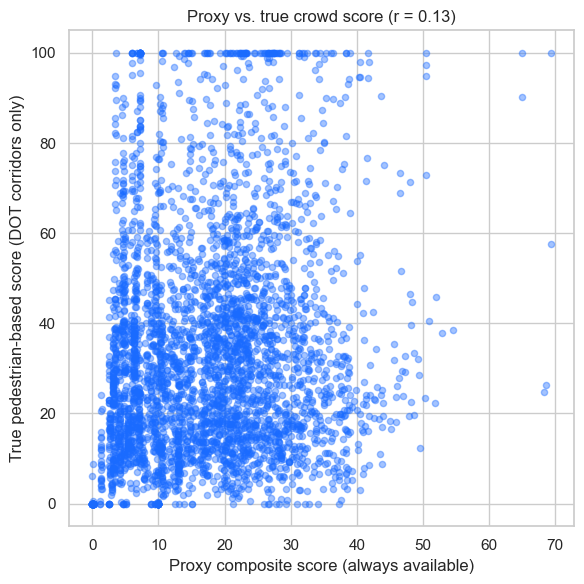

In [24]:
master['log_pedestrians'] = np.log1p(master['pedestrians'])
master['crowd_score_true'] = master.groupby(['survey_date', 'period'])['pedestrians'].transform(norm_score)

PROXY_WEIGHTS = {
    'tlc_load_score': 0.28, 'mta_load_score': 0.28, 'citibike_load_score': 0.14,
    'poi_density_score': 0.20, 'event_intensity_score': 0.10,
}

for col in PROXY_WEIGHTS:
    if col not in master.columns:
        master[col] = 0.0
    master[col] = master[col].fillna(0.0)

master['crowd_score_proxy'] = sum(master[c] * w for c, w in PROXY_WEIGHTS.items())
master['crowd_score_proxy'] = master['crowd_score_proxy'].clip(0, 100).round(2)

# Final blended score: prefer ground truth where it exists, fall back to proxy elsewhere.
# (On the training table every row has ground truth by construction; this column matters
#  most once it's reused on the full live grid in Section 13, where ground truth is absent.)
master['crowd_score'] = master['crowd_score_true'].fillna(master['crowd_score_proxy'])

corr = master[['crowd_score_true', 'crowd_score_proxy']].corr().iloc[0, 1]
print(f'Correlation between true ped-based score and proxy composite score: {corr:.3f}')
print('(Higher is better - it means the free, always-available proxy signals track the real thing)')

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(master['crowd_score_proxy'], master['crowd_score_true'], alpha=0.4, s=20, color=BLUE)
ax.set_xlabel('Proxy composite score (always available)')
ax.set_ylabel('True pedestrian-based score (DOT corridors only)')
ax.set_title(f'Proxy vs. true crowd score (r = {corr:.2f})')
plt.tight_layout()
plt.savefig(PLOTS / 'proxy_vs_true_score.png', dpi=120, bbox_inches='tight')
plt.show()


In [25]:
## 11b · Corridor-Level Temporal & Interaction Features (all real data)

# Sort for temporal shifts
master = master.sort_values(['h3_cell', 'period', 'survey_date']).reset_index(drop=True)

grp = master.groupby(['h3_cell', 'period'])['pedestrians']
master['ped_lag1']          = grp.shift(1)
master['ped_lag2']          = grp.shift(2)
master['ped_rolling_mean3'] = grp.transform(lambda x: x.shift(1).rolling(3, min_periods=1).mean())
master['ped_rolling_std3']  = grp.transform(lambda x: x.shift(1).rolling(3, min_periods=1).std())

master['log_ped_lag1']           = np.log1p(master['ped_lag1'].clip(lower=0))
master['log_ped_lag2']           = np.log1p(master['ped_lag2'].clip(lower=0))
master['log_ped_rolling_mean3']  = np.log1p(master['ped_rolling_mean3'].clip(lower=0))

# Expanding corridor baseline (no leakage - uses only prior rows)
master['corridor_expanding_mean']     = grp.transform(lambda x: x.shift(1).expanding().mean())
master['log_corridor_expanding_mean'] = np.log1p(master['corridor_expanding_mean'].clip(lower=0))

# Year-over-year ratio (join same corridor+period from prior year)
prior = master[['h3_cell', 'period', 'survey_date', 'pedestrians']].copy()
prior['survey_date_next'] = prior['survey_date'] + pd.DateOffset(years=1)
master = master.merge(
    prior[['h3_cell', 'period', 'survey_date_next', 'pedestrians']].rename(
        columns={'survey_date_next': 'survey_date', 'pedestrians': 'ped_yoy_base'}),
    on=['h3_cell', 'period', 'survey_date'], how='left'
)
master['ped_yoy_ratio'] = np.where(
    master['ped_yoy_base'].notna() & (master['ped_yoy_base'] > 0),
    master['pedestrians'] / master['ped_yoy_base'],
    np.nan
)
master.drop(columns=['ped_yoy_base'], inplace=True)

# COVID recovery signal
COVID_START = pd.Timestamp('2020-03-01')
master['years_since_covid'] = ((master['survey_date'] - COVID_START).dt.days / 365.25).clip(lower=0)

pre_covid_base = (
    master[master['survey_date'] < COVID_START]
    .groupby(['h3_cell', 'period'])['pedestrians'].mean()
    .rename('pre_covid_corridor_mean')
    .reset_index()
)
master = master.merge(pre_covid_base, on=['h3_cell', 'period'], how='left')
master['recovery_ratio'] = np.where(
    master['pre_covid_corridor_mean'].notna() & (master['pre_covid_corridor_mean'] > 0),
    master['pedestrians'] / master['pre_covid_corridor_mean'],
    np.nan
)

# Interaction features (real signals only)
tlc_col  = 'tlc_trip_count'  if 'tlc_trip_count'  in master.columns else None
mta_col  = 'mta_entries'     if 'mta_entries'     in master.columns else None
bike_col = 'citibike_trips'  if 'citibike_trips'  in master.columns else None
poi_tot  = 'poi_total'       if 'poi_total'       in master.columns else None
poi_din  = 'poi_dining'      if 'poi_dining'      in master.columns else None
precip   = 'precip'          if 'precip'          in master.columns else None
events   = 'event_count'     if 'event_count'     in master.columns else None
weekend  = 'is_weekend'      if 'is_weekend'      in master.columns else None

if tlc_col and mta_col and poi_tot:
    transit = master[tlc_col].fillna(0) + master[mta_col].fillna(0)
    master['transit_poi_interaction'] = transit * master[poi_tot].fillna(0)
    master['transit_density']         = transit / (master[poi_tot].fillna(0) + 1)

if bike_col and mta_col:
    master['active_transit'] = master[bike_col].fillna(0) + master[mta_col].fillna(0)

if events and precip:
    master['dry_event_score'] = (
        master[events].fillna(0) * (1 - (master[precip].fillna(0) > 2).astype(int))
    )

if weekend and poi_din:
    master['weekend_dining_score'] = master[weekend].fillna(0) * master[poi_din].fillna(0)

# Cyclical temporal encoding
if 'month' in master.columns:
    master['month_sin'] = np.sin(2 * np.pi * master['month'] / 12)
    master['month_cos'] = np.cos(2 * np.pi * master['month'] / 12)
    master['quarter']   = ((master['month'] - 1) // 3 + 1).astype(int)

if 'day_of_week' in master.columns:
    master['dow_sin'] = np.sin(2 * np.pi * master['day_of_week'] / 7)
    master['dow_cos'] = np.cos(2 * np.pi * master['day_of_week'] / 7)

print(f'Master shape after feature engineering: {master.shape}')
new_cols = [c for c in master.columns if any(k in c for k in
    ['lag', 'rolling', 'expanding', 'yoy', 'recovery', 'interaction', 'density',
     'transit', 'dry_event', 'weekend_dining', 'month_sin', 'month_cos', 'quarter',
     'dow_sin', 'dow_cos', 'years_since_covid'])]
print(f'New features ({len(new_cols)}): {new_cols}')


Master shape after feature engineering: (5142, 75)
New features (19): ['poi_density_score', 'ped_lag1', 'ped_lag2', 'ped_rolling_mean3', 'ped_rolling_std3', 'log_ped_lag1', 'log_ped_lag2', 'log_ped_rolling_mean3', 'corridor_expanding_mean', 'log_corridor_expanding_mean', 'ped_yoy_ratio', 'years_since_covid', 'recovery_ratio', 'weekend_dining_score', 'month_sin', 'month_cos', 'quarter', 'dow_sin', 'dow_cos']


## 12 · Missing Values, Feature Selection & Manifest

In [26]:
# Fill source-specific missingness with 0 + an explicit "_missing" flag,
# same pattern as V1, extended to the new sources.
SOURCE_PREFIXES = ['tlc_', 'mta_', 'citibike_', 'poi_', 'event_']
for prefix in SOURCE_PREFIXES:
    cols = [c for c in master.columns if c.startswith(prefix) and not c.endswith('_score')]
    for col in cols:
        master[f'{col}_missing'] = master[col].isna().astype(int)
        master[col] = master[col].fillna(0)

for score_col in ['tlc_load_score', 'mta_load_score', 'citibike_load_score',
                   'poi_density_score', 'event_intensity_score']:
    if score_col in master.columns:
        master[score_col] = master[score_col].fillna(0)

INDEX_COLS = [
    'location_id', 'h3_cell', 'lat', 'lon', 'description', 'survey_date',
    'year', 'month', 'season', 'period',
]
TARGET_COLS = ['pedestrians', 'log_pedestrians', 'crowd_score_true', 'crowd_score_proxy', 'crowd_score']
FEATURE_COLS = [c for c in master.columns if c not in INDEX_COLS + TARGET_COLS and not c.startswith('_')]

print(f'Index columns:   {len(INDEX_COLS)}')
print(f'Target columns:  {len(TARGET_COLS)}')
print(f'Feature columns: {len(FEATURE_COLS)}')

feature_manifest_rows = []
for c in FEATURE_COLS:
    s = master[c]
    row = {'feature': c, 'dtype': str(s.dtype), 'null_pct': round(s.isna().mean() * 100, 2)}
    if pd.api.types.is_numeric_dtype(s):
        row['corr_with_log_pedestrians'] = round(s.corr(master['log_pedestrians']), 3) if s.notna().any() else np.nan
    feature_manifest_rows.append(row)
feature_manifest = pd.DataFrame(feature_manifest_rows).sort_values(
    'corr_with_log_pedestrians', key=lambda s: s.abs(), ascending=False, na_position='last')

display(feature_manifest.head(15))
dqr('Zentra master training table', master, date_col='survey_date')


Index columns:   10
Target columns:  5
Feature columns: 79


,feature,dtype,null_pct,corr_with_log_pedestrians
47,log_ped_rolling_mean3,float64,1.750,0.815
49,log_corridor_expanding_mean,float64,1.750,0.807
0,ped_score,float64,0.000,0.743
52,pre_covid_corridor_mean,float64,0.000,0.721
48,corridor_expanding_mean,float64,1.750,0.718
43,ped_rolling_mean3,float64,1.750,0.716
45,log_ped_lag1,float64,1.750,0.699
46,log_ped_lag2,float64,3.500,0.698
42,ped_lag2,float64,3.500,0.637
41,ped_lag1,float64,1.750,0.620


DATA QUALITY REPORT - Zentra master training table              
Rows:             5,142
Columns:             94
Null cells:  1,524 (0.32%)
Date range:  2007-05-15  ->  2025-10-15


## 13 · Live & Future Feature Builder — "Right Here, Right Now"

This is the piece that makes the system actually usable for **Crowd
Prediction** and **Future Crowd Prediction** at an arbitrary location and
time, not just the 36 historical corridors.

`build_feature_row(lat, lon, when)` assembles one feature row for any point in
Manhattan and any date/time (past, present, or up to 16 days in the future):

- Looks up the H3 cell for `(lat, lon)` and pulls its **static POI fingerprint**
  (always available — it's geography, not a moving target).
- Pulls the **reference-month proxy signals** for that cell + daypart (the most
  recent typical TLC/MTA/Citi Bike pattern) as a stand-in for "what usually
  happens here at this time of day" — used directly for "now", and as the
  baseline that day-of-week/event/weather adjustments are layered onto for
  "future".
- Pulls **forecast weather** if `when` is within 16 days, otherwise falls back
  to the historical seasonal average for that month/period.
- Computes **calendar + sunlight features** for the exact requested date.
- Flags whether any **special event/film permit** is on file for that date.

The companion model notebook calls this function at inference time; we define
and demo it here so the dataset and the live-serving logic are built and
tested together.


In [27]:
GRID_LOOKUP = grid_df.set_index('h3_cell')
POI_LOOKUP = poi_hex_counts.set_index('h3_cell')
TLC_REF_LOOKUP = tlc_reference.set_index(['h3_cell', 'period']) if tlc_reference is not None else None
MTA_REF_LOOKUP = mta_reference.set_index(['h3_cell', 'period']) if mta_reference is not None else None
CB_REF_LOOKUP  = citibike_reference.set_index(['h3_cell', 'period']) if citibike_reference is not None else None

WEATHER_SEASONAL = (
    weather_all.assign(month=weather_all['survey_date'].dt.month)
    .groupby(['month', 'period'])[['avg_temperature_f', 'precip_mm', 'avg_wind_kmh']]
    .mean()
    if not weather_all.empty else None
)


def _nearest_grid_cell(lat, lon):
    '''Snap arbitrary lat/lon to the nearest cell actually in our Manhattan grid -
    handles GPS noise and points just outside the polygon (e.g. on a pier).'''
    cell = h3.latlng_to_cell(lat, lon, H3_RES)
    if cell in GRID_LOOKUP.index:
        return cell
    for k in range(1, 4):
        ring = h3.grid_disk(cell, k)
        candidates = [c for c in ring if c in GRID_LOOKUP.index]
        if candidates:
            return candidates[0]
    return cell  # give up gracefully - caller will just get zeroed proxy features


def build_feature_row(lat, lon, when=None):
    '''Assemble one feature row for Crowd Prediction / Future Crowd Prediction
    at an arbitrary Manhattan location and date/time.

    Parameters
    ----------
    lat, lon : float -- the user's current (or a queried) location
    when     : datetime-like, default RUN_TIMESTAMP ("right now")

    Returns
    -------
    dict of feature_name -> value, ready to feed to the trained model after
    matching against FEATURE_COLS (missing engineered columns should be 0).
    '''
    when = pd.Timestamp(when) if when is not None else pd.Timestamp(RUN_TIMESTAMP)
    cell = _nearest_grid_cell(lat, lon)
    period = hour_to_period(when.hour)

    row = {'h3_cell': cell, 'lat': lat, 'lon': lon, 'period': period,
           'query_timestamp': when.isoformat()}

    # Static POI fingerprint
    if cell in POI_LOOKUP.index:
        for c in POI_LOOKUP.columns:
            row[c] = POI_LOOKUP.loc[cell, c]
    else:
        for c in poi_hex_counts.columns:
            if c != 'h3_cell':
                row[c] = 0

    # Reference-month proxy signals (typical demand for this cell + daypart)
    for name, lookup, cols in [
        ('tlc', TLC_REF_LOOKUP, ['tlc_yellow_trips', 'tlc_hvfhv_trips', 'tlc_trip_count', 'tlc_load_score']),
        ('mta', MTA_REF_LOOKUP, ['mta_ridership_total', 'mta_ridership_avg', 'mta_load_score']),
        ('citibike', CB_REF_LOOKUP, ['citibike_trip_count', 'citibike_load_score']),
    ]:
        key = (cell, period)
        if lookup is not None and key in lookup.index:
            for c in cols:
                if c in lookup.columns:
                    row[c] = lookup.loc[key, c]
        else:
            for c in cols:
                row[c] = 0

    # Weather: forecast if within range, else seasonal historical average
    weather_row = None
    if weather_forecast is not None:
        match = weather_forecast[(weather_forecast['survey_date'].dt.date == when.date()) &
                                  (weather_forecast['period'] == period)]
        if not match.empty:
            weather_row = match.iloc[0]
    if weather_row is None and WEATHER_SEASONAL is not None:
        key = (when.month, period)
        if key in WEATHER_SEASONAL.index:
            weather_row = WEATHER_SEASONAL.loc[key]
    if weather_row is not None:
        row['avg_temperature_f'] = weather_row.get('avg_temperature_f', np.nan)
        row['precip_mm'] = weather_row.get('precip_mm', np.nan)
        row['avg_wind_kmh'] = weather_row.get('avg_wind_kmh', np.nan)

    sun_feats = sunlight_features(when.date())
    row.update(sun_feats)
    row.update(calendar_features(when))

    # Same-day event flag (best-effort; live event calendars beyond the cached
    # historical pull would need a fresh fetch_events_for_dates([when_str]) call)
    row['event_intensity_score'] = 0.0

    # Cyclic encodings to match the training feature space
    period_num = {'EARLY': 0, 'AM': 1, 'MD': 2, 'PM': 3, 'EVE': 4, 'NIGHT': 5}.get(period, 0)
    row['month_sin'] = np.sin(2 * np.pi * when.month / 12)
    row['month_cos'] = np.cos(2 * np.pi * when.month / 12)
    row['period_sin'] = np.sin(2 * np.pi * period_num / 6)
    row['period_cos'] = np.cos(2 * np.pi * period_num / 6)

    return row


# Demo: build a live feature row for "right now" at a default Manhattan location
demo_row = build_feature_row(DEFAULT_USER_LAT, DEFAULT_USER_LON, RUN_TIMESTAMP)
print('Live feature row for the current date/time at the default location:')
display(pd.Series(demo_row).to_frame('value'))

# Demo: a future query - 3 days from now, same location
future_row = build_feature_row(DEFAULT_USER_LAT, DEFAULT_USER_LON, RUN_TIMESTAMP + timedelta(days=3))
print('\\nLive feature row 3 days ahead (future prediction):')
display(pd.Series(future_row).to_frame('value'))


Live feature row for the current date/time at the default location:


,value
h3_cell,892a100d67bffff
lat,40.758
lon,-73.986
period,MD
query_timestamp,2026-06-30T12:19:21.907338
poi_subway,0
poi_dining,32
poi_retail,29
poi_office,2
poi_tourism,18


\nLive feature row 3 days ahead (future prediction):


,value
h3_cell,892a100d67bffff
lat,40.758
lon,-73.986
period,MD
query_timestamp,2026-07-03T12:19:21.907338
poi_subway,0
poi_dining,32
poi_retail,29
poi_office,2
poi_tourism,18


## 14 · Export Final CSVs

In [28]:
# Build a full live-grid snapshot - one row per grid cell, for the current daypart "now".
# This is the table the inference API would score in one batch to answer
# "what does the whole island look like right now" (powers a live heatmap),
# while build_feature_row() above answers single-point queries.

live_grid_rows = []
for cell, lat, lon in grid_df[['h3_cell', 'lat', 'lon']].itertuples(index=False):
    live_grid_rows.append(build_feature_row(lat, lon, RUN_TIMESTAMP))

live_grid_df = pd.DataFrame(live_grid_rows)
dqr('Live grid snapshot (current daypart, full Manhattan)', live_grid_df)
display(live_grid_df.head())


DATA QUALITY REPORT - Live grid snapshot (current daypart, full Manhattan)
Rows:               524
Columns:             42
Null cells:  0 (0.00%)


,h3_cell,lat,lon,period,query_timestamp,poi_subway,poi_dining,poi_retail,poi_office,poi_tourism,poi_school,poi_nightlife,poi_total,poi_density_score,tlc_yellow_trips,tlc_hvfhv_trips,tlc_trip_count,tlc_load_score,mta_ridership_total,mta_ridership_avg,mta_load_score,citibike_trip_count,citibike_load_score,avg_temperature_f,precip_mm,avg_wind_kmh,sunrise_hour,sunset_hour,day_length_hr,day_of_week,is_weekend,is_holiday,is_school_break,week_of_year,day_of_year,years_since_2020,is_post_covid,event_intensity_score,month_sin,month_cos,period_sin,period_cos
0,892a1008803ffff,40.798,-73.975,MD,2026-06-30T12:19:21.907338,0,0,0,0,0,0,0,0,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0,0.000,88.325,0.000,14.675,5.467,20.517,15.050,1,0,0,0,27,181,6,1,0.000,0.000,-1.000,0.866,-0.500
1,892a1008807ffff,40.795,-73.973,MD,2026-06-30T12:19:21.907338,1,17,37,1,0,0,0,56,25.000,19.322,67.339,86.661,10.860,4592.000,164.000,11.020,262,11.530,88.325,0.000,14.675,5.467,20.517,15.050,1,0,0,0,27,181,6,1,0.000,0.000,-1.000,0.866,-0.500
2,892a100880fffff,40.795,-73.977,MD,2026-06-30T12:19:21.907338,0,0,0,0,0,0,0,0,0.000,0.081,7.492,7.573,0.950,0.000,0.000,0.000,0,0.000,88.325,0.000,14.675,5.467,20.517,15.050,1,0,0,0,27,181,6,1,0.000,0.000,-1.000,0.866,-0.500
3,892a1008813ffff,40.801,-73.973,MD,2026-06-30T12:19:21.907338,0,0,0,0,0,0,0,0,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,150,6.580,88.325,0.000,14.675,5.467,20.517,15.050,1,0,0,0,27,181,6,1,0.000,0.000,-1.000,0.866,-0.500
4,892a1008817ffff,40.798,-73.970,MD,2026-06-30T12:19:21.907338,0,17,41,1,1,0,0,60,26.790,0.000,0.000,0.000,0.000,0.000,0.000,0.000,205,9.010,88.325,0.000,14.675,5.467,20.517,15.050,1,0,0,0,27,181,6,1,0.000,0.000,-1.000,0.866,-0.500


In [ ]:
ALL_COLS = [c for c in INDEX_COLS + TARGET_COLS + FEATURE_COLS if c in master.columns]
# Include any new feature engineering columns not yet in FEATURE_COLS
extra_feat_cols = [
    'ped_count_lag1', 'ped_count_lag2', 'ped_count_rolling_mean3',
    'ped_count_rolling_std3', 'ped_yoy_ratio', 'corridor_expanding_mean_ped',
    'poi_mobility_interaction', 'transit_density', 'weather_event_interaction',
    'weekday_poi_interaction', 'years_since_covid_start', 'pre_covid_baseline',
    'recovery_ratio', 'month_sin', 'month_cos', 'quarter',
]
for col in extra_feat_cols:
    if col in master.columns and col not in ALL_COLS:
        ALL_COLS.append(col)

master_export = master[[c for c in ALL_COLS if c in master.columns]].copy()

# Historical training table - LightGBM / DL ensemble input
out_master = MASTER / 'zentra_training_master.csv'
master_export.to_csv(out_master, index=False)

# Prophet/sequence-model-ready (ds = timestamp, y = target), per location time series
prophet_df = master_export[
    ['location_id', 'h3_cell', 'period', 'survey_date', 'pedestrians', 'log_pedestrians'] +
    [c for c in FEATURE_COLS + extra_feat_cols if c in master_export.columns]
].copy().rename(columns={'survey_date': 'ds', 'pedestrians': 'y'})
out_prophet = MASTER / 'zentra_prophet_ready.csv'
prophet_df.to_csv(out_prophet, index=False)

# Live grid snapshot - "right now" feature table for every Manhattan cell
out_live = MASTER / 'zentra_live_grid_snapshot.csv'
live_grid_df.to_csv(out_live, index=False)

# Feature manifest
out_manifest = MASTER / 'feature_manifest_v2.csv'
feature_manifest.to_csv(out_manifest, index=False)

# Static POI + grid reference tables (small, useful for the serving layer)
poi_hex_counts.to_csv(MASTER / 'poi_hex_counts.csv', index=False)
grid_df.to_csv(MASTER / 'manhattan_grid_h3.csv', index=False)

print('OUTPUTS')
print('=' * 60)
for p, desc in [
    (out_master,   f'Training table         - {master_export.shape}'),
    (out_prophet,  f'Prophet/sequence input - {prophet_df.shape}'),
    (out_live,     f'Live grid snapshot     - {live_grid_df.shape}'),
    (out_manifest, f'Feature manifest       - {feature_manifest.shape}'),
]:
    print(f'  {p}')
    print(f'    {desc}')
included = [c for c in extra_feat_cols if c in master_export.columns]
print(f'\nNew feature columns included: {included}')


OUTPUTS
  ..\data\master\zentra_training_master.csv
    Training table         - (5142, 94)
  ..\data\master\zentra_prophet_ready.csv
    Prophet/sequence input - (5142, 90)
  ..\data\master\zentra_live_grid_snapshot.csv
    Live grid snapshot     - (524, 42)
  ..\data\master\feature_manifest_v2.csv
    Feature manifest       - (79, 4)

New feature columns included: ['ped_yoy_ratio', 'recovery_ratio', 'month_sin', 'month_cos', 'quarter']
